완료한 내용
- received → completed
    - duration 안
    - 시간 순서 고려


추가해야 하는 방식
- received → viewed : 열람률
    - 오퍼가 실제로 고객에게 읽혔는가

- received → completed : 전체 완료율
    - 오퍼를 받은 사람 중 최종적으로 조건 충족까지 간 비율

- viewed → completed : 열람 후 완료율
    - 오퍼를 본 사람 중 실제 행동까지 이어진 비율
    
- received → viewed → completed : 정상 퍼널 완료율
    - received 이후 viewed를 거치고, 그 다음 completed까지 순서대로 간 비율

In [67]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 사용 함수

In [68]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [69]:
# 컬럼 분포 확인
def check_category_summary(df, df_name, col_name):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 {col_name} 범주 확인")
    print(f"{'='*80}\n")
    
    summary_df = df[col_name].value_counts(dropna=False).reset_index()
    summary_df.columns = [col_name, '개수']
    summary_df['비율(%)'] = (summary_df['개수'] / len(df) * 100).round(2)
    
    display(summary_df.head(10))

# 데이터 로드

In [70]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("data/transcript_portfolio_profile.csv")

# 테이블 복제
# informational은 completed 개념이 없으니 제거하고 시작
# 필요시 그냥 df2 = df.copy() 사용
# df2 = df[df['offer_type'] != 'informational'].copy()
df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,306137
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,10.84,272955,89.16,4
amount,float64,138953,45.39,167184,54.61,5103
offer_id,str,167184,54.61,138953,45.39,10
offer_reward,float64,167184,54.61,138953,45.39,5
difficulty,float64,167184,54.61,138953,45.39,5
duration,float64,167184,54.61,138953,45.39,5
channels,str,167184,54.61,138953,45.39,4
offer_type,str,167184,54.61,138953,45.39,3
web,float64,167184,54.61,138953,45.39,2
mobile,float64,167184,54.61,138953,45.39,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


전환율 기준 = completed / received\
단, duration 안에서 일어난 completed만 인정

시간 순서를 고려해\
고객 세그먼트, reward, difficulty, channel, offer_type 같은 변수와 붙여 분석

추가적으로
time_completed_rc : received → completed용 completed 시간\
time_completed_vc : viewed → completed용 completed 시간\

플래그 추가 생성
converted_rv : received → viewed\
converted_rc : received → completed\
converted_vc : viewed → completed\
converted_rvc : received → viewed → completed

# received / completed 이벤트 분리
전환율의 분모와 분자 생성

In [71]:
# ============================================================
# received / viewed / completed 이벤트 분리
# ============================================================
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# viewed 분리
viewed = (
    df2[df2['event'] == 'offer viewed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_viewed'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("viewed 행 수:", len(viewed))
print("completed 행 수:", len(completed))

received 행 수: 76277
viewed 행 수: 57725
completed 행 수: 33182


# 시간순 정렬
customer_id + offer_id 기준으로 시간순 번호를 붙여 맞추기

원래 seq 방식으로 n번째 received와 n번째 completed를 연결하고자 했으나\
같은 고객이 같은 오퍼를 이전 오퍼 유효기간이 끝나기 전에 또 받은 경우 문제가 발생할수도 있어 변경

completed보다 먼저 온 received만 후보로 보고, 그중 가장 최근 received를 연결하는 구조로 변경

코드 실행 시간이 매우 깁니다. (대략 10분)

추가적으로 조건에 맞는 received가 없으면 그냥 넘어갑니다.\
completed는 있었지만 연결 실패한 케이스는 match_df에 저장되지 않습니다.

In [72]:
# ============================================================
# 정렬 + 기준키 생성
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

viewed = viewed.sort_values(
    ["customer_id", "offer_id", "time_viewed"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 기준 고유 행 번호 만들기
received["received_idx"] = received.index

# 오퍼 유효 종료 시점
received["offer_end_time"] = received["time_received"] + received["duration"] * 24

In [73]:
# ============================================================
# 공통 매칭 함수
# - event를 가장 최근의 유효한 base 이벤트에 연결
# - 시간 순서 맞게
# - duration 안의 이벤트만 인정
# - 1대1방식으로 (한 base는 같은 방식에서 1번만 사용)
# - 매칭 함수
# ============================================================
def match_event_to_base_slow(
        base_df,           # 기준이 되는 이벤트 테이블(received 또는 viewed)
        event_df,          # base에 연결할 이벤트 테이블(viewed 또는 completed)
        base_time_col,     # base 이벤트의 시간 컬럼명
        event_time_col,    # 연결할 event의 시간 컬럼명
        matched_time_col,  # 매칭 후 result에 새로 붙일 시간 컬럼명
        base_id_col="received_idx"  # base 행을 구분하는 고유 식별 컬럼명
        ):
    
    # 매칭 결과를 저장할 리스트
    match_rows = []

    # base 이벤트(received 또는 viewed?) 고객, 오퍼, 시간 순서대로 정렬
    # 후보 선택 시 시간 순서를 안정적으로 보기 위함
    base_sorted = base_df.sort_values(
        ["customer_id", "offer_id", base_time_col]
    ).copy()

    # event 이벤트(viewed 또는 completed) 고객, 오퍼, 시간 순서대로 정렬
    # 이벤트 발생 순서대로 base와 연결
    event_sorted = event_df.sort_values(
        ["customer_id", "offer_id", event_time_col]
    ).copy()

    # event를 customer_id + offer_id 단위로 묶어서 반복
    for (customer_id, offer_id), event_group in event_sorted.groupby(["customer_id", "offer_id"]):
    # 같은 고객이 같은 오퍼에 대해 발생시킨 event끼리만 봄

        # 현재 customer_id + offer_id에 해당하는 base 이벤트들만 따로 추출
        base_group = base_sorted[
            (base_sorted["customer_id"] == customer_id) &
            (base_sorted["offer_id"] == offer_id)
        ].copy()

        # 이미 매칭된 received는 다시 쓰지 않기 위한 집합
        used_base = set()

        # event 발생 시간을 하나씩 확인하면서 조건에 맞는 base 찾기
        for event_time in event_group[event_time_col]:

            # 현재 event_time에 대해 연결 가능한 base 후보 찾기
            candidates = base_group[
                # 조건 1 base 시간이 event 시간보다 같거나 이전
                # 시간 순서상 base가 먼저 발생해야 함
                (base_group[base_time_col] <= event_time) &
                # 조건 2 event가 offer_end_time 이내
                # duration 안에서 일어난 이벤트만 인정
                (event_time <= base_group["offer_end_time"]) &
                # 조건 3 아직 사용되지 않은 base여
                # 같은 received/viewed에 event 여러 개 중복 매칭 방지
                (~base_group[base_id_col].isin(used_base))
            ].copy()

            # 후보가 없으면 다음 completed로
            if len(candidates) == 0:
                continue

            # 후보가 여러 개면 그중 가장 최근의 유효한 base 선택
            best_base = candidates.sort_values(base_time_col, ascending=False).iloc[0]

            # 매칭 결과 저장
            match_rows.append({
                base_id_col: best_base[base_id_col],
                matched_time_col: event_time
            })

            # 사용한 received는 다시 못 쓰게 저장
            used_base.add(best_base[base_id_col])

    # 최종 결과는 base_df를 기준으로 유지
    result = base_df.copy()

    # 매칭 결과가 하나도 없으면 결측치로 만든 뒤 반환
    if len(match_rows) == 0:
        result[matched_time_col] = pd.NA
        return result

    # base_df와 매칭 결과를 base_id_col 기준으로 왼쪽 병합
    match_df = pd.DataFrame(match_rows)

    result = result.merge(
        match_df,
        on=base_id_col,
        how="left"
    )

    return result

In [74]:
# ============================================================
# 공통 매칭 함수
# - event를 가장 최근의 유효한 base 이벤트에 연결
# - 시간 순서 맞게
# - duration 안의 이벤트만 인정
# - 1대1방식으로 (한 base는 같은 방식에서 1번만 사용)
# - 속도 개선 버전
# ============================================================
def match_event_to_base(
        base_df,           # 기준이 되는 이벤트 테이블(received 또는 viewed)
        event_df,          # base에 연결할 이벤트 테이블(viewed 또는 completed)
        base_time_col,     # base 이벤트의 시간 컬럼명
        event_time_col,    # 연결할 event의 시간 컬럼명
        matched_time_col,  # 매칭 후 result에 새로 붙일 시간 컬럼명
        base_id_col="received_idx"  # base 행을 구분하는 고유 식별 컬럼명
        ):
    """
    received 또는 viewed를 기준으로 잡고 그 뒤에 일어난 viewed/completed를
    같은 고객과 같은 오퍼 안에서 가장 최근의 유효한 base에 1대1로 연결
    """
    
    # 매칭 결과를 저장할 리스트
    match_rows = []

    # base 이벤트(received 또는 viewed?) 고객, 오퍼, 시간 순서대로 정렬
    # -> 불필요한 컬럼을 줄여서 속도와 메모리 사용을 줄임
    base_sorted = (
        base_df[["customer_id", "offer_id", base_id_col, base_time_col, "offer_end_time"]]
        .sort_values(["customer_id", "offer_id", base_time_col])
        .reset_index(drop=True)
    )

    # event 이벤트(viewed 또는 completed) 고객, 오퍼, 시간 순서대로 정렬
    # 이벤트 발생 순서대로 base와 연결
    event_sorted = (
        event_df[["customer_id", "offer_id", event_time_col]]
        .sort_values(["customer_id", "offer_id", event_time_col])
        .reset_index(drop=True)
    )

    # base를 customer_id + offer_id 그룹별로 한 번만 저장
    # -> 반복문 안에서 base_group을 계속 다시 찾지 않기 위함
    # -> numpy 배열로 바꿔서 더 빠르게 처리
    base_groups = {
        key: group[[base_id_col, base_time_col, "offer_end_time"]].to_numpy()
        for key, group in base_sorted.groupby(["customer_id", "offer_id"], sort=False)
    }

    # event를 customer_id + offer_id 단위로 묶어서 반복
    for key, event_group in event_sorted.groupby(["customer_id", "offer_id"], sort=False):

        # 현재 그룹에 해당하는 base 가져오기
        bases = base_groups.get(key)

        # 해당 고객+오퍼의 base가 아예 없으면 다음 그룹으로
        if bases is None:
            continue

        # numpy 배열에서 필요한 값 분리
        # base_ids        : base 행의 고유 식별값
        # base_times      : base 발생 시간
        # offer_end_times : 각 base의 유효 종료 시점
        base_ids = bases[:, 0]
        base_times = bases[:, 1].astype(float)
        offer_end_times = bases[:, 2].astype(float)

        # 같은 방식에서 한 base는 1번만 사용
        # -> 이미 사용한 base는 True로 바뀜
        used = np.zeros(len(bases), dtype=bool)

        # event 발생 시간을 하나씩 확인하면서 조건에 맞는 base 찾기
        for event_time in event_group[event_time_col].to_numpy(dtype=float):

            # event_time 이하인 base 중
            # 가장 최근 base 위치를 빠르게 찾음
            # -> searchsorted는 정렬된 배열에서 위치를 빠르게 찾는 함수
            j = np.searchsorted(base_times, event_time, side="right") - 1

            # 가장 최근 후보부터 뒤에서 앞으로 확인
            # -> event와 가장 가까운 이전 base를 선택하기 위함
            while j >= 0:

                # 조건 1 아직 사용되지 않은 base인가?
                # 조건 2 event가 offer_end_time 이내인가?
                # -> duration 안에서 일어난 이벤트만 인정
                if (not used[j]) and (offer_end_times[j] >= event_time):
                    match_rows.append({
                        base_id_col: base_ids[j],
                        matched_time_col: event_time
                    })

                    # 사용한 base는 다시 못 쓰게 저장
                    used[j] = True
                    break

                # 조건이 안 맞으면 더 이전 base를 확인
                j -= 1

    # 최종 결과는 base_df를 기준으로 유지
    result = base_df.copy()

    # 매칭 결과가 하나도 없으면 결측치로 만든 뒤 반환
    if not match_rows:
        result[matched_time_col] = pd.NA
        return result

    # 매칭 결과 리스트를 DataFrame으로 변환
    match_df = pd.DataFrame(match_rows)

    # base_df와 매칭 결과를 base_id_col 기준으로 왼쪽 병합
    # -> 매칭 성공한 행은 시간값이 붙고
    # -> 실패한 행은 NaN으로 남음
    result = result.merge(
        match_df,
        on=base_id_col,
        how="left"
    )

    return result

# 4개 전환 기준 테이블 생성

In [75]:
# ============================================================
# 1) received -> viewed 매칭
# ============================================================
rv = match_event_to_base(
    base_df=received,
    event_df=viewed,
    base_time_col="time_received",
    event_time_col="time_viewed",
    matched_time_col="time_viewed"
)

In [76]:
# ============================================================
# 2) received -> completed 매칭
# ============================================================
rc_match = match_event_to_base(
    base_df=received,                    # 기준: 받은 오퍼(received)
    event_df=completed,                  # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_received",       # 기준 시간: 오퍼 받은 시점
    event_time_col="time_completed",     # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_rc" # 결과로 붙일 컬럼명(received→completed용)
)


In [77]:
# ============================================================
# 3) viewed -> completed 매칭
# viewed가 붙은 received만 대상으로, viewed 이후 completed를 다시 매칭
# ============================================================
view_base = rv[rv["time_viewed"].notna()].copy()

vc_match = match_event_to_base(
    base_df=view_base,                  # 기준: viewed가 확인된 received
    event_df=completed,                 # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_viewed",        # 기준 시간: 오퍼 본 시점
    event_time_col="time_completed",    # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_vc" # 결과로 붙일 컬럼명(viewed→completed용)
)

In [78]:
# ============================================================
# 최종 received 기준 퍼널 테이블 생성
# ============================================================
funnel = received.copy()

# received -> viewed 매칭 결과 붙이기
funnel = funnel.merge(
    rv[["received_idx", "time_viewed"]],
    on="received_idx",
    how="left"
)

# received -> completed 매칭 결과 붙이기
funnel = funnel.merge(
    rc_match[["received_idx", "time_completed_rc"]],
    on="received_idx",
    how="left"
)

# 시간 차이 계산
# 각 단계까지 걸린 시간을 계산
funnel = funnel.merge(
    vc_match[["received_idx", "time_completed_vc"]],
    on="received_idx",
    how="left"
)

# 시간 차이
funnel["rv_time_diff"] = funnel["time_viewed"] - funnel["time_received"]
funnel["rc_time_diff"] = funnel["time_completed_rc"] - funnel["time_received"]
funnel["vc_time_diff"] = funnel["time_completed_vc"] - funnel["time_viewed"]

# 유효 여부 플래그
# 시간값이 존재하면 1, 없으면 0으로 변환
funnel["has_viewed"] = funnel["time_viewed"].notna().astype(int)
funnel["has_completed_rc"] = funnel["time_completed_rc"].notna().astype(int)
funnel["has_completed_after_view"] = funnel["time_completed_vc"].notna().astype(int)

# 전환 플래그
# converted_rv  : received -> viewed 전환 여부
funnel["converted_rv"] = funnel["has_viewed"]

# converted_rc  : received -> completed 전환 여부
funnel["converted_rc"] = funnel["has_completed_rc"]

# converted_vc  : viewed -> completed 전환 여부
funnel["converted_vc"] = funnel["has_completed_after_view"]

# converted_rvc : received -> viewed -> completed 전환 여부
funnel["converted_rvc"] = (
    (funnel["has_viewed"] == 1) &
    (funnel["has_completed_after_view"] == 1)
).astype(int)

# 기존 코드 호환용
# 기존 converted_final 의미를 유지하려면 received -> completed로 둠
funnel["converted_final"] = funnel["converted_rc"]

In [79]:
# ------------------------------------------------------------
# 퍼널 분석에 필요한 핵심 컬럼만 선택해서 최종 테이블 형태로 정리
# ------------------------------------------------------------
funnel = funnel[
    [
        'customer_id', 'offer_id',                          # 고객 / 오퍼 식별 정보
        'offer_type', 'offer_reward', 'difficulty', 'duration',   # 오퍼 속성 정보
        'web', 'email', 'mobile', 'social',                # 오퍼 발송 채널 정보

        'time_received', 'offer_end_time',                 # 오퍼 수신 시점 / 오퍼 유효 종료 시점
        'time_viewed', 'time_completed_rc', 'time_completed_vc',   # 단계별 매칭 시간 정보

        'rv_time_diff', 'rc_time_diff', 'vc_time_diff',    # 단계별 소요 시간 정보

        'has_viewed', 'has_completed_rc', 'has_completed_after_view',  # 이벤트 연결 여부 플래그

        'converted_rv', 'converted_rc', 'converted_vc', 'converted_rvc', # 전환 여부 플래그
        'converted_final'                                  # 기존 코드 호환용 최종 전환 컬럼
    ]
].copy()

# ------------------------------------------------------------
# 최종 funnel 테이블의 기본 정보(행/열 수, 결측치, 타입 등) 확인
# ------------------------------------------------------------
check_basic_info(funnel, 'received 기준 funnel 테이블')


received 기준 funnel 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,26
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed_vc,float64,23496,30.80,52781,69.20,120
vc_time_diff,float64,23496,30.80,52781,69.20,41
time_completed_rc,float64,33152,43.46,43125,56.54,120
rc_time_diff,float64,33152,43.46,43125,56.54,41
time_viewed,float64,56567,74.16,19710,25.84,120
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,time_viewed,time_completed_rc,time_completed_vc,rv_time_diff,rc_time_diff,vc_time_diff,has_viewed,has_completed_rc,has_completed_after_view,converted_rv,converted_rc,converted_vc,converted_rvc,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,576.0,NaN,NaN,0.0,NaN,0,1,0,0,1,0,0,1
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,372.0,NaN,NaN,36.0,NaN,NaN,1,0,0,1,0,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,192.0,NaN,NaN,24.0,NaN,NaN,1,0,0,1,0,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,456.0,414.0,NaN,48.0,6.0,NaN,1,1,0,1,1,0,0,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,540.0,528.0,NaN,36.0,24.0,NaN,1,1,0,1,1,0,0,1


# 완성물 해설

- customer_id               : 고객 식별 ID
- offer_id                  : 오퍼 식별 ID

- offer_type                : 오퍼 유형(bogo, discount, informational 등)
- offer_reward              : 오퍼 보상값
- difficulty                : 오퍼 완료 조건 금액/난이도
- duration                  : 오퍼 유효기간(일 단위)

- web                       : 웹 채널 발송 여부
- email                     : 이메일 채널 발송 여부
- mobile                    : 모바일 채널 발송 여부
- social                    : 소셜 채널 발송 여부

- time_received             : 오퍼를 받은 시점
- offer_end_time            : 오퍼 유효 종료 시점(time_received + duration*24)
- time_viewed               : received 이후 매칭된 viewed 시점
- time_completed_rc         : received 이후 매칭된 completed 시점
- time_completed_vc         : viewed 이후 매칭된 completed 시점

- rv_time_diff              : received 후 viewed까지 걸린 시간
- rc_time_diff              : received 후 completed까지 걸린 시간
- vc_time_diff              : viewed 후 completed까지 걸린 시간

- has_viewed                : viewed 매칭 여부(있으면 1, 없으면 0)
- has_completed_rc          : received 기준 completed 매칭 여부(있으면 1, 없으면 0)
- has_completed_after_view  : viewed 기준 completed 매칭 여부(있으면 1, 없으면 0)

- converted_rv              : received -> viewed 전환 여부 : 열람률
- converted_rc              : received -> completed 전환 여부 : 전체 완료율
- converted_vc              : viewed -> completed 전환 여부 : 열람 후 완료율
- converted_rvc             : received -> viewed -> completed 전환 여부 : 정상 퍼널 완료율

- converted_final           : 기존 코드 호환용 최종 전환 컬럼(received -> completed 기준)


In [80]:
# 오퍼 반응 퍼널 분석에 필요한 핵심 컬럼만 선별
# 식별자, 오퍼 속성, 채널, 기준 시점, 시간차, 전환 여부 중심으로 구성
funnel_clean = funnel[
    [
        'customer_id',      # 고객 식별 ID
        'offer_id',         # 오퍼 식별 ID

        'offer_type',       # 오퍼 유형(bogo, discount, informational 등)
        'offer_reward',     # 오퍼 보상값
        'difficulty',       # 오퍼 완료 조건 금액/난이도
        'duration',         # 오퍼 유효기간(일 단위)

        'web',              # 웹 채널 발송 여부
        'email',            # 이메일 채널 발송 여부
        'mobile',           # 모바일 채널 발송 여부
        'social',           # 소셜 채널 발송 여부

        'time_received',    # 오퍼를 받은 시점
        'offer_end_time',   # 오퍼 유효 종료 시점(time_received + duration*24)

        'rv_time_diff',     # received 후 viewed까지 걸린 시간
        'rc_time_diff',     # received 후 completed까지 걸린 시간
        'vc_time_diff',     # viewed 후 completed까지 걸린 시간

        'converted_rv',     # received -> viewed 전환 여부
        'converted_rc',     # received -> completed 전환 여부
        'converted_vc',     # viewed -> completed 전환 여부
        'converted_rvc'     # received -> viewed -> completed 전환 여부
    ]
].copy()

# converted_final
# 기존 코드 호환용 컬럼으로, converted_rc와 의미가 겹쳐 제외

# has_viewed, has_completed_rc, has_completed_after_view
# 매칭 여부 컬럼이지만 rv, rc, vc가  더 직관적으로 보여주므로 제외

# time_viewed, time_completed_rc, time_completed_vc
# 상세 시점 확인용 컬럼

# 고객 세그먼트 변수(age, gender, income, became_member_on)는 추후 필요 시 merge

check_basic_info(funnel_clean, ' funnel_clean 테이블')


 funnel_clean 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,19
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
vc_time_diff,float64,23496,30.80,52781,69.20,41
rc_time_diff,float64,33152,43.46,43125,56.54,41
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6
offer_reward,float64,76277,100.00,0,0.00,5
difficulty,float64,76277,100.00,0,0.00,5
duration,float64,76277,100.00,0,0.00,5


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,0.0,NaN,0,1,0,0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,36.0,NaN,NaN,1,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,24.0,NaN,NaN,1,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0


# 검증단계

In [81]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

received_count = len(funnel_clean)
viewed_count = funnel_clean["converted_rv"].sum()
completed_rc_count = funnel_clean["converted_rc"].sum()
completed_vc_count = funnel_clean["converted_vc"].sum()
strict_funnel_count = funnel_clean["converted_rvc"].sum()

rv_rate = viewed_count / received_count * 100 if received_count > 0 else 0
rc_rate = completed_rc_count / received_count * 100 if received_count > 0 else 0
vc_rate = completed_vc_count / viewed_count * 100 if viewed_count > 0 else 0
rvc_rate = strict_funnel_count / received_count * 100 if received_count > 0 else 0

print("received 기준 전체 건수:", received_count)
print("viewed가 붙은 건수:", viewed_count)
print("completed(received 기준)가 붙은 건수:", completed_rc_count)
print("completed(viewed 기준)가 붙은 건수:", completed_vc_count)
print("strict funnel 완료 건수:", strict_funnel_count)
print()

print("received → viewed 전환율:", round(rv_rate, 2), "%")
print("received → completed 전환율:", round(rc_rate, 2), "%")
print("viewed → completed 전환율:", round(vc_rate, 2), "%")
print("received → viewed → completed 전환율:", round(rvc_rate, 2), "%")

기본 검증단계
received 기준 전체 건수: 76277
viewed가 붙은 건수: 56567
completed(received 기준)가 붙은 건수: 33152
completed(viewed 기준)가 붙은 건수: 23496
strict funnel 완료 건수: 23496

received → viewed 전환율: 74.16 %
received → completed 전환율: 43.46 %
viewed → completed 전환율: 41.54 %
received → viewed → completed 전환율: 30.8 %


# 주의 

구매 전환율이 아니라 오퍼 유효 완료 전환율임


분석할 내용들

1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가?
2. 어떤 채널 조합에서 오퍼 반응률이 더 높은가?
3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
5. 이 결과를 마케팅 실무자가 빠르게 해석할 수 있도록 Tableau 대시보드로 구현한다.

# 1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가?
고객 특성에 따라 어떤 프로모션 유형에 더 잘 반응하는가?


- 고객 세그먼트 종류
    - gender
    - age
    - income
    - became_member_on

- 사용 지표
    - `converted_rv` : 오퍼를 받은 뒤 실제로 열람했는가
    - `converted_rc` : 오퍼를 받은 뒤 완료했는가
    - `converted_rvc` : 오퍼를 받고, 열람 후, 완료까지 이어졌는가


## 1. 고객 세그먼트 정보 준비

In [82]:
# 1. 고객 세그먼트 정보 준비

# 고객 기준 프로필 정보만 추출
profile_base = (
    df2[[
        'customer_id', 
        'gender',
        'age', 
        'income', 
        'became_member_on']]
    .drop_duplicates(subset=['customer_id'])
    .copy()
)
print("profile_base 고객 수:", profile_base['customer_id'].nunique())

# funnel_clean에 고객 세그먼트 정보 붙이기
funnel_seg = funnel_clean.merge(
    profile_base,
    on='customer_id',
    how='left'
)

print("funnel_seg 행 수:", len(funnel_seg))
print("funnel_seg 고객 수:", funnel_seg['customer_id'].nunique())
display(funnel_seg.head())

profile_base 고객 수: 17000
funnel_seg 행 수: 76277
funnel_seg 고객 수: 16994


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc,gender,age,income,became_member_on
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,0.0,NaN,0,1,0,0,M,33.0,72000.0,2017-04-21
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,36.0,NaN,NaN,1,0,0,0,M,33.0,72000.0,2017-04-21
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,24.0,NaN,NaN,1,0,0,0,M,33.0,72000.0,2017-04-21
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21


In [83]:
# ============================================================
# profile 전체 고객과 funnel 기준 고객 비교
# ============================================================

all_profile_customers = set(profile_base['customer_id'])
funnel_customers = set(funnel_clean['customer_id'])

missing_customers = sorted(all_profile_customers - funnel_customers)

print("profile 전체 고객 수:", len(all_profile_customers))
print("funnel 고객 수:", len(funnel_customers))
print("빠진 고객 수:", len(missing_customers))

# 빠진 고객들의 transcript 이벤트 확인
missing_event_check = (
    df2[df2['customer_id'].isin(missing_customers)]
    .groupby(['customer_id', 'event'])
    .size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'event'])
)

display(missing_event_check)

profile 전체 고객 수: 17000
funnel 고객 수: 16994
빠진 고객 수: 6


,customer_id,event,count
0,12ede229379747bd8d74ccdc20097ca3,transaction,3
1,3a4874d8f0ef42b9a1b72294902afea9,transaction,3
2,ae8111e7e8cd4b60a8d35c42c1110555,transaction,5
3,c6e579c6821c41d1a7a6a9cf936e91bb,transaction,4
4,da7a7c0dcfcb41a8acc7864a53cf60fb,transaction,1
5,eb540099db834cf59001f83a4561aef3,transaction,4


고객수가 6명 빠진 이유?
- profile에는 있는데 received 기준 퍼널(funnel_clean)에는 한 번도 들어오지 않은 고객
- 즉, 전체 고객 17,000명 중 6명은 아예 offer received 이벤트가 없었다

# 2. 세그먼트 그룹핑

1. gender_group
    - F
    - M
    - O
    - Missing

2. age_group
    - 18-29
    - 30-39
    - 40-49
    - 50-59
    - 60-69
    - 70+
    - Missing

3. income_group
    - 30k-49k
    - 50k-69k
    - 70k-89k
    - 90k+
    - Missing

4. member_cohort
    - 2013~2014
    - 2015~2016
    - 2017~2018
    - Missing

In [84]:
funnel_seg = funnel_seg.copy()

# ======================================================================================
# 1. gender_group
funnel_seg['gender_group'] = (
    funnel_seg['gender']
    .fillna('Missing')
)
# ======================================================================================

# ======================================================================================
# 2. age_group
funnel_seg['age_clean'] = (
    funnel_seg['age']
    .where(
        funnel_seg['age']
        .between(18, 100),pd.NA)
)

funnel_seg['age_group'] = pd.cut(
    funnel_seg['age_clean'],
    bins=[18, 30, 40, 50, 60, 70, float('inf')],
    right=False,
    labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
)

funnel_seg['age_group'] = funnel_seg['age_group'].astype('object').fillna('Missing')
# ======================================================================================

# ======================================================================================
# 3. income_group
funnel_seg['income_group'] = pd.cut(
    funnel_seg['income'],
    bins=[30000, 50000, 70000, 90000, float('inf')],
    right=False,
    labels=['30k-49k', '50k-69k', '70k-89k', '90k+']
)

funnel_seg['income_group'] = funnel_seg['income_group'].astype('object').fillna('Missing')
# ======================================================================================

# ======================================================================================
# 4. member_cohort
funnel_seg['became_member_on'] = funnel_seg['became_member_on'].astype('string')
funnel_seg['member_year'] = pd.to_numeric(
    funnel_seg['became_member_on'].str[:4],
    errors='coerce'
)

funnel_seg['member_cohort'] = pd.cut(
    funnel_seg['member_year'],
    bins=[2013, 2015, 2017, 2019],
    right=False,
    labels=['2013-2014', '2015-2016', '2017-2018']
)

funnel_seg['member_cohort'] = funnel_seg['member_cohort'].astype('object').fillna('Missing')
# ======================================================================================

# 최종확인
display(
    funnel_seg[
        [
            'customer_id', 'gender', 'gender_group',
            'age', 'age_group',
            'income', 'income_group',
            'became_member_on', 'member_year', 'member_cohort'
        ]
    ].head(10)
)

,customer_id,gender,gender_group,age,age_group,income,income_group,became_member_on,member_year,member_cohort
0,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
1,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
2,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
3,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
4,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
5,00116118485d4dfda04fdbaba9a87b5c,NaN,Missing,NaN,Missing,NaN,Missing,<NA>,<NA>,Missing
6,00116118485d4dfda04fdbaba9a87b5c,NaN,Missing,NaN,Missing,NaN,Missing,<NA>,<NA>,Missing
7,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018
8,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018
9,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018


# 3. 세그멘트별 기본 분포 확인

In [85]:
# ============================================================
# 세그먼트별 기본 분포 확인
# ============================================================
check_category_summary(funnel_seg, "funnel_seg", 'gender_group')
check_category_summary(funnel_seg, "funnel_seg", 'age_group')
check_category_summary(funnel_seg, "funnel_seg", 'income_group')
check_category_summary(funnel_seg, "funnel_seg", 'member_cohort')



funnel_seg의 gender_group 범주 확인



,gender_group,개수,비율(%)
0,M,38129,49.99
1,F,27456,36.00
2,Missing,9776,12.82
3,O,916,1.20



funnel_seg의 age_group 범주 확인



,age_group,개수,비율(%)
0,50-59,15894,20.84
1,60-69,13423,17.60
2,70+,12885,16.89
3,40-49,10288,13.49
4,Missing,9799,12.85
5,18-29,7095,9.30
6,30-39,6893,9.04



funnel_seg의 income_group 범주 확인



,income_group,개수,비율(%)
0,50k-69k,22428,29.40
1,30k-49k,16967,22.24
2,70k-89k,16783,22.00
3,90k+,10323,13.53
4,Missing,9776,12.82



funnel_seg의 member_cohort 범주 확인



,member_cohort,개수,비율(%)
0,2017-2018,41632,54.58
1,2015-2016,20670,27.10
2,Missing,9776,12.82
3,2013-2014,4199,5.50


# 4. 세그먼트 × 프로모션 유형 반응률 요약표

In [86]:
# ============================================================
# 세그먼트 × offer_type 반응률 요약 함수
# ============================================================

def make_segment_offer_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum'),
            completed_cnt=('converted_rc', 'sum'),
            strict_completed_cnt=('converted_rvc', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100
    summary['rc_rate'] = summary['completed_cnt'] / summary['received_cnt'] * 100
    summary['rvc_rate'] = summary['strict_completed_cnt'] / summary['received_cnt'] * 100

    summary = summary.sort_values([segment_col, 'offer_type']).reset_index(drop=True)
    
    return summary

In [87]:
gender_offer_summary = make_segment_offer_summary(funnel_seg, 'gender_group')
age_offer_summary = make_segment_offer_summary(funnel_seg, 'age_group')
income_offer_summary = make_segment_offer_summary(funnel_seg, 'income_group')
cohort_offer_summary = make_segment_offer_summary(funnel_seg, 'member_cohort')

In [88]:
print("=" * 70)
print("gender × offer_type top 5")
print("=" * 70)
display(gender_offer_summary.head(5))

print("=" * 70)
print("age_group × offer_type top 5")
print("=" * 70)
display(age_offer_summary.head(5))

print("=" * 70)
print("income_group × offer_type top 5")
print("=" * 70)
display(income_offer_summary.head(5))

print("=" * 70)
print("member_cohort × offer_type top 5")
print("=" * 70)
display(cohort_offer_summary.head(5))

gender × offer_type top 5


,gender_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,F,bogo,10975,9065,7434,5254,82.596811,67.735763,47.872437
1,F,discount,10943,7700,7876,5253,70.364617,71.972951,48.003290
2,F,informational,5538,3530,0,0,63.741423,0.000000,0.000000
3,M,bogo,15208,12485,7425,5281,82.094950,48.822988,34.725145
4,M,discount,15354,10396,8817,6374,67.708740,57.424775,41.513612


age_group × offer_type top 5


,age_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,18-29,bogo,2831,2298,1186,790,81.172730,41.893324,27.905334
1,18-29,discount,2888,1708,1483,995,59.141274,51.350416,34.452909
2,18-29,informational,1376,823,0,0,59.811047,0.000000,0.000000
3,30-39,bogo,2710,2202,1339,960,81.254613,49.409594,35.424354
4,30-39,discount,2805,1811,1629,1159,64.563280,58.074866,41.319073


income_group × offer_type top 5


,income_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,30k-49k,bogo,6781,5379,2607,1764,79.324583,38.445657,26.013862
1,30k-49k,discount,6837,4012,3381,2343,58.680708,49.451514,34.269416
2,30k-49k,informational,3349,1977,0,0,59.032547,0.000000,0.000000
3,50k-69k,bogo,8886,7576,4880,3610,85.257709,54.917848,40.625703
4,50k-69k,discount,8965,6511,5519,4110,72.626882,61.561629,45.844953


member_cohort × offer_type top 5


,member_cohort,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,2013-2014,bogo,1667,1388,714,525,83.263347,42.831434,31.493701
1,2013-2014,discount,1686,1162,1148,902,68.920522,68.090154,53.499407
2,2013-2014,informational,846,547,0,0,64.657210,0.000000,0.000000
3,2015-2016,bogo,8260,6837,6239,4489,82.772397,75.532688,54.346247
4,2015-2016,discount,8295,5822,6854,4720,70.186860,82.628089,56.901748


# 세그먼트별 전체 반응률

In [89]:
# ============================================================
# 세그먼트별 전체 반응률 요약
# ============================================================

def make_segment_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum'),
            completed_cnt=('converted_rc', 'sum'),
            strict_completed_cnt=('converted_rvc', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100
    summary['rc_rate'] = summary['completed_cnt'] / summary['received_cnt'] * 100
    summary['rvc_rate'] = summary['strict_completed_cnt'] / summary['received_cnt'] * 100

    summary = summary.sort_values('received_cnt', ascending=False).reset_index(drop=True)
    return summary

In [90]:
# ============================================================
# 7. 세그먼트별 전체 반응률 확인
# ============================================================
gender_summary = make_segment_summary(funnel_seg, 'gender_group')
age_summary = make_segment_summary(funnel_seg, 'age_group')
income_summary = make_segment_summary(funnel_seg, 'income_group')
cohort_summary = make_segment_summary(funnel_seg, 'member_cohort')

In [91]:
print("=" * 70)
print("gender 전체 반응률")
print("=" * 70)
display(gender_summary)

print("=" * 70)
print("age_group 전체 반응률")
print("=" * 70)
display(age_summary)

print("=" * 70)
print("income_group 전체 반응률")
print("=" * 70)
display(income_summary)

print("=" * 70)
print("member_cohort 전체 반응률")
print("=" * 70)
display(cohort_summary)

gender 전체 반응률


,gender_group,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,M,38129,27779,16242,11655,72.855307,42.597498,30.567285
1,F,27456,20295,15310,10507,73.918269,55.761946,38.268502
2,Missing,9776,7724,1105,944,79.009820,11.303191,9.656301
3,O,916,769,495,390,83.951965,54.039301,42.576419


age_group 전체 반응률


,age_group,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,50-59,15894,11748,8168,5682,73.914685,51.390462,35.749339
1,60-69,13423,9931,6838,4761,73.984951,50.942412,35.468971
2,70+,12885,9438,6597,4570,73.247963,51.199069,35.467598
3,40-49,10288,7993,4795,3627,77.692457,46.607698,35.254666
4,Missing,9799,7740,1117,952,78.987652,11.399122,9.715277
5,18-29,7095,4829,2669,1785,68.062016,37.618041,25.158562
6,30-39,6893,4888,2968,2119,70.912520,43.058175,30.741332


income_group 전체 반응률


,income_group,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,50k-69k,22428,17313,10399,7720,77.193686,46.366149,34.421259
1,30k-49k,16967,11368,5988,4107,67.000648,35.292037,24.205811
2,70k-89k,16783,12752,9417,6641,75.981648,56.110350,39.569803
3,90k+,10323,7410,6243,4084,71.781459,60.476606,39.562143
4,Missing,9776,7724,1105,944,79.009820,11.303191,9.656301


member_cohort 전체 반응률


,member_cohort,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,2017-2018,41632,30380,17092,11916,72.972713,41.054958,28.622214
1,2015-2016,20670,15366,13093,9209,74.339623,63.343009,44.552492
2,Missing,9776,7724,1105,944,79.009820,11.303191,9.656301
3,2013-2014,4199,3097,1862,1427,73.755656,44.343891,33.984282


# 시각화

## 그래프 함수

In [107]:
import seaborn as sns

segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['18-29', '30-39', '40-49', '50-59', '60-69', '70+', 'Missing'],
    'income_group': ['30k-49k', '50k-69k', '70k-89k', '90k+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}


In [108]:
# 세그먼트 × 프로모션 유형 반응률 막대그래프 함수
def plot_segment_offer_box(summary_df, segment_col, rate_col, group_title):
    
    # 데이터 복사
    df_a = summary_df.copy()
    
    # 세그먼트 순서 정리
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
    
    # offer_type 순서
    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    
    df_a = df_a.sort_values(['offer_type', segment_col])
    
    # 지표명 한글 변환
    rate_name_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)
    
    # 프로모션 유형 1개당 1행
    offer_types = [x for x in offer_order if x in df_a['offer_type'].dropna().unique()]
    n_rows = len(offer_types)
    
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, n_rows * 4))
    
    # 1행일 때도 리스트 형태 유지
    if n_rows == 1:
        axes = [axes]
    
    for i, offer in enumerate(offer_types):
        temp_df = df_a[df_a['offer_type'] == offer].copy()
        
        sns.barplot(
            data=temp_df,
            x=segment_col,
            y=rate_col,
            ax=axes[i]
        )
        
        axes[i].set_title(f"{offer} - {rate_name}", fontsize=12, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("반응률(%)")
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        # 막대 위 수치 표시
        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )
    
    fig.suptitle(f"[{group_title}] 세그먼트 × 프로모션 유형 {rate_name} 비교", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

In [109]:
# 세그먼트별 전체 반응률 막대그래프 함수
def plot_segment_summary_box(summary_df, segment_col, group_title):
    
    # 데이터 복사
    df_a = summary_df.copy()
    
    # 세그먼트 순서 정리
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)
    
    # 그릴 지표 목록
    metric_cols = ['rv_rate', 'rc_rate', 'rvc_rate']
    metric_names = ['열람률', '완료율', '정상 퍼널 완료율']
    
    # 지표 1개당 1행
    n_rows = len(metric_cols)
    
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, n_rows * 4))
    
    # 지표가 1개일 때도 형태 유지
    if n_rows == 1:
        axes = [axes]
    
    for i, (metric_col, metric_name) in enumerate(zip(metric_cols, metric_names)):
        sns.barplot(
            data=df_a,
            x=segment_col,
            y=metric_col,
            ax=axes[i]
        )
        
        axes[i].set_title(f"{metric_name} 비교", fontsize=12, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("반응률(%)")
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        # 막대 위 수치 표시
        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )
    
    fig.suptitle(f"[{group_title}] 세그먼트별 전체 반응률 비교", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

In [110]:
# 세그먼트 × 오퍼 유형 히트맵 함수
def plot_segment_offer_heatmap(summary_df, segment_col, rate_col, group_title):
    
    # 데이터 복사
    df_a = summary_df.copy()
    
    # 세그먼트 순서 정렬
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
    
    # offer_type 순서 정렬
    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    
    df_a = df_a.sort_values([segment_col, 'offer_type'])
    
    # 지표명 한글 변환
    rate_name_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)
    
    # 피벗 테이블 생성
    pivot_df = df_a.pivot(
        index=segment_col,
        columns='offer_type',
        values=rate_col
    )
    
    # 그래프
    fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_df) * 0.7)))
    im = ax.imshow(pivot_df, aspect='auto')
    
    # 축 설정
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    
    # 셀 안 수치 표시
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j, i,
                    f"{value:.1f}",
                    ha='center',
                    va='center',
                    fontsize=9
                )
    
    plt.title(f"[{group_title}] 세그먼트 × 오퍼 유형 {rate_name} 히트맵")
    plt.xlabel("offer_type")
    plt.ylabel(segment_col)
    plt.colorbar(im, ax=ax, label='반응률(%)')
    plt.tight_layout()
    plt.show()
    
    return df_a

In [111]:
# 세그먼트별 전체 반응률 히트맵 함수
def plot_segment_summary_heatmap(summary_df, segment_col, group_title):
    
    # 데이터 복사
    df_a = summary_df.copy()
    
    # 세그먼트 순서 정렬
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)
    
    # 표시용 컬럼만 선택
    heatmap_df = df_a[[segment_col, 'rv_rate', 'rc_rate', 'rvc_rate']].copy()
    
    # 컬럼명 한글 변경
    heatmap_df = heatmap_df.rename(columns={
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    })
    
    # pivot처럼 index 지정
    heatmap_df = heatmap_df.set_index(segment_col)
    
    # 그래프 크기
    fig, ax = plt.subplots(figsize=(7, max(4, len(heatmap_df) * 0.7)))
    
    # 히트맵 그리기
    im = ax.imshow(heatmap_df, aspect='auto')
    
    # 축 설정
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    
    # 셀 안 수치 표시
    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            value = heatmap_df.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j, i,
                    f"{value:.1f}",
                    ha='center',
                    va='center',
                    fontsize=9
                )
    
    plt.title(f"[{group_title}] 세그먼트별 전체 반응률 히트맵")
    plt.xlabel("반응 지표")
    plt.ylabel(segment_col)
    plt.colorbar(im, ax=ax, label='반응률(%)')
    plt.tight_layout()
    plt.show()
    
    return df_a

## 그래프 사용

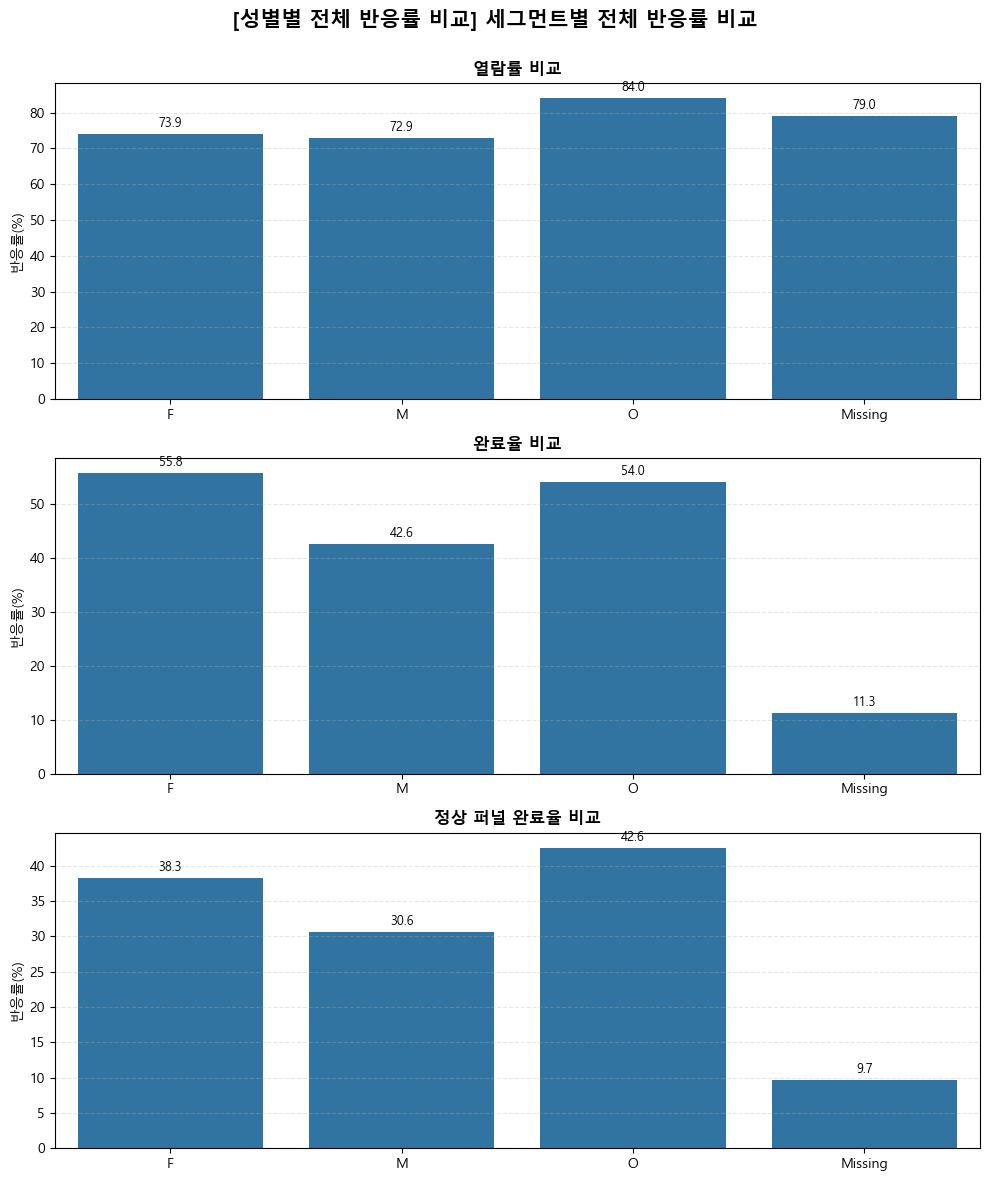

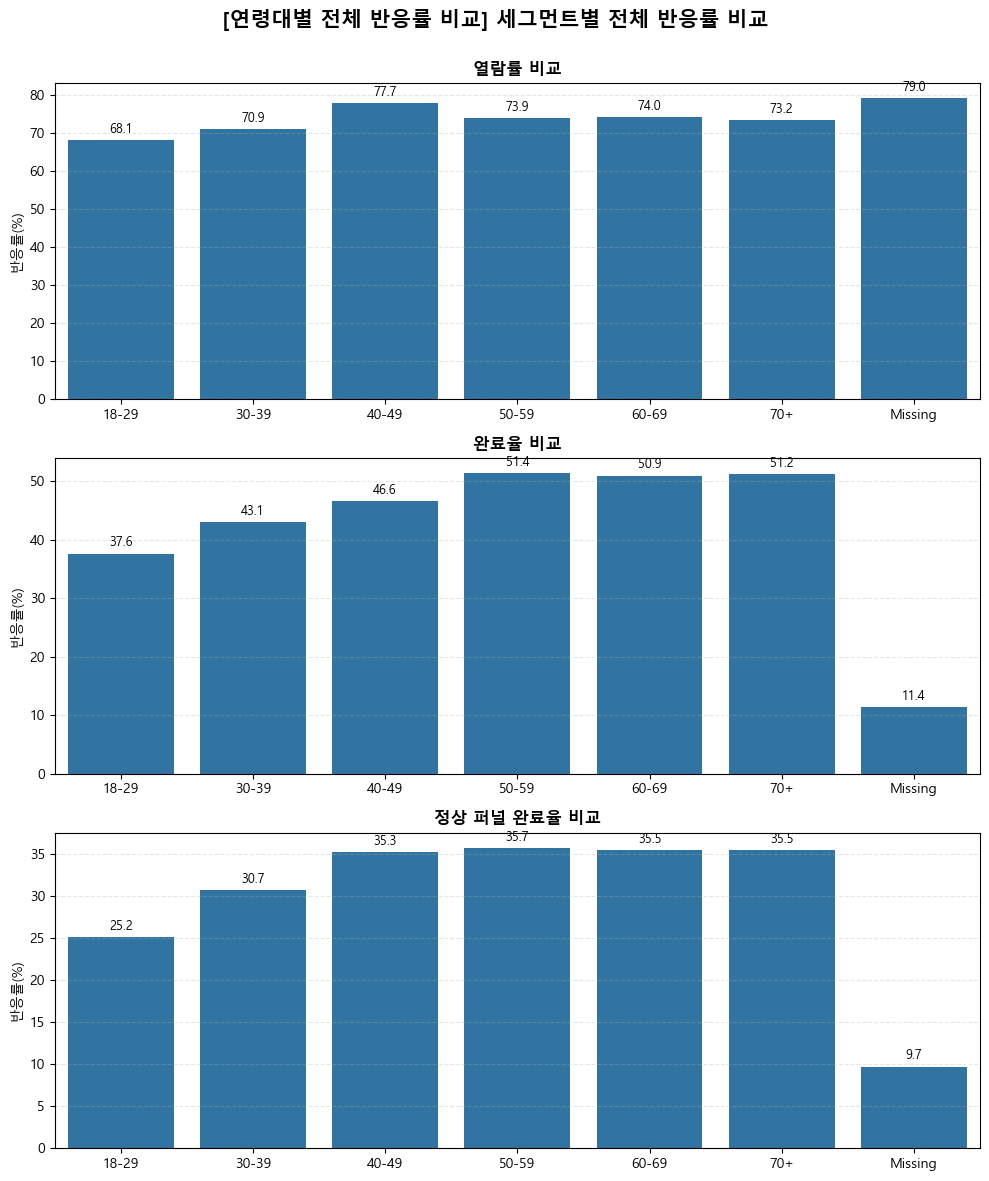

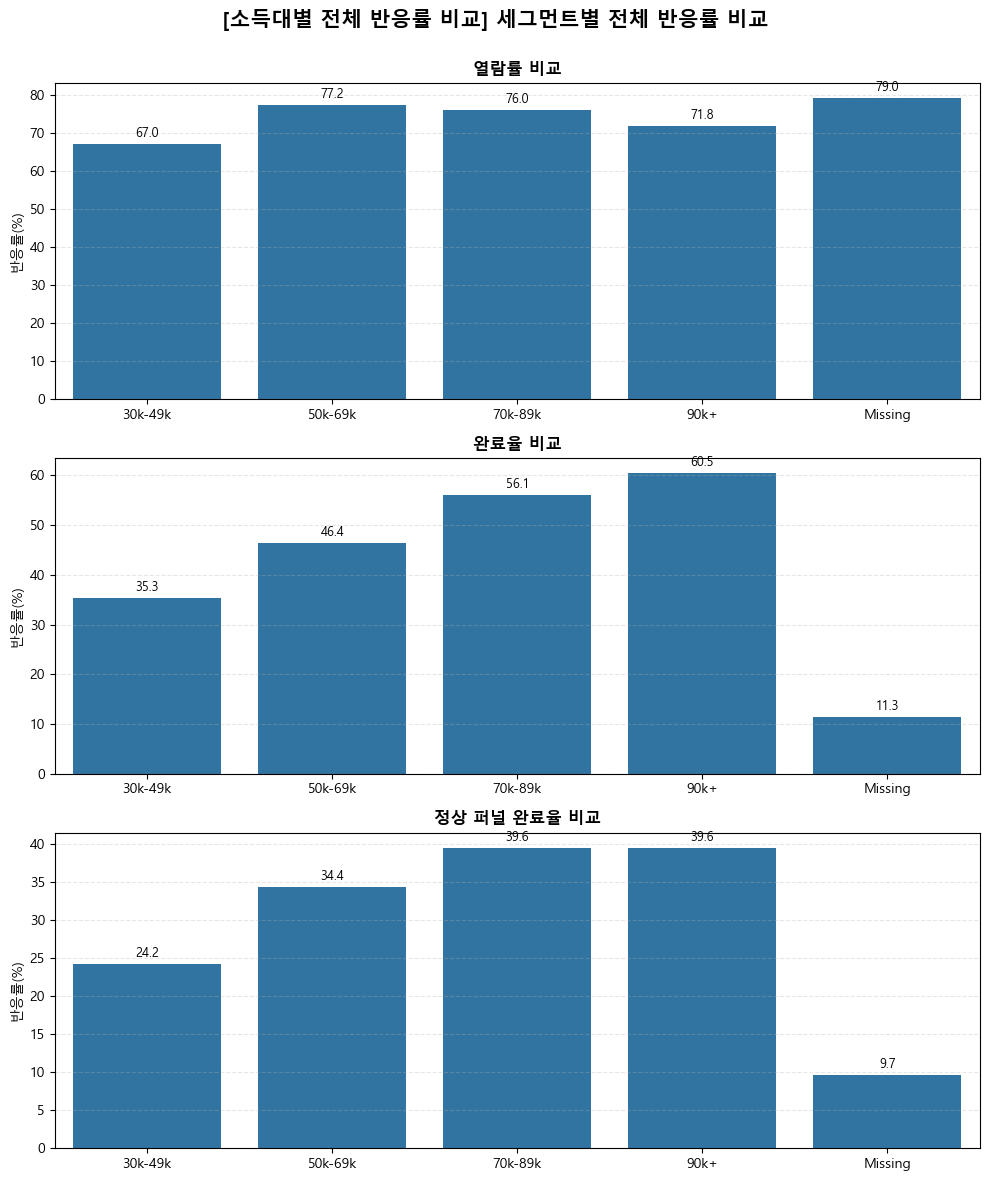

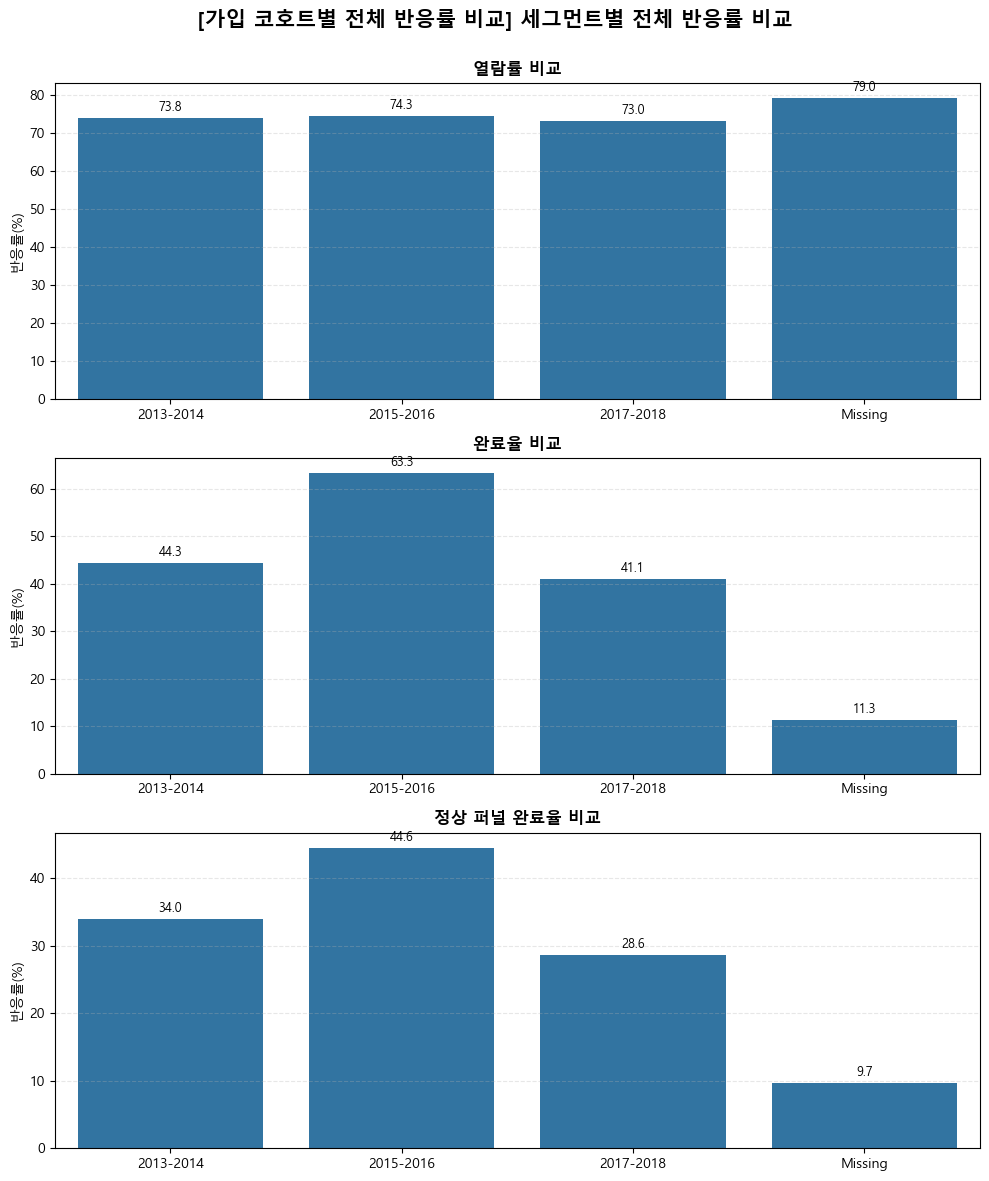

,member_cohort,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
3,2013-2014,4199,3097,1862,1427,73.755656,44.343891,33.984282
1,2015-2016,20670,15366,13093,9209,74.339623,63.343009,44.552492
0,2017-2018,41632,30380,17092,11916,72.972713,41.054958,28.622214
2,Missing,9776,7724,1105,944,79.009820,11.303191,9.656301


In [112]:
plot_segment_summary_box(
    gender_summary, 
    'gender_group', 
    '성별별 전체 반응률 비교'
)

plot_segment_summary_box(
    age_summary, 
    'age_group', 
    '연령대별 전체 반응률 비교'
)

plot_segment_summary_box(
    income_summary, 
    'income_group', 
    '소득대별 전체 반응률 비교'
)

plot_segment_summary_box(
    cohort_summary, 
    'member_cohort', 
    '가입 코호트별 전체 반응률 비교'
)

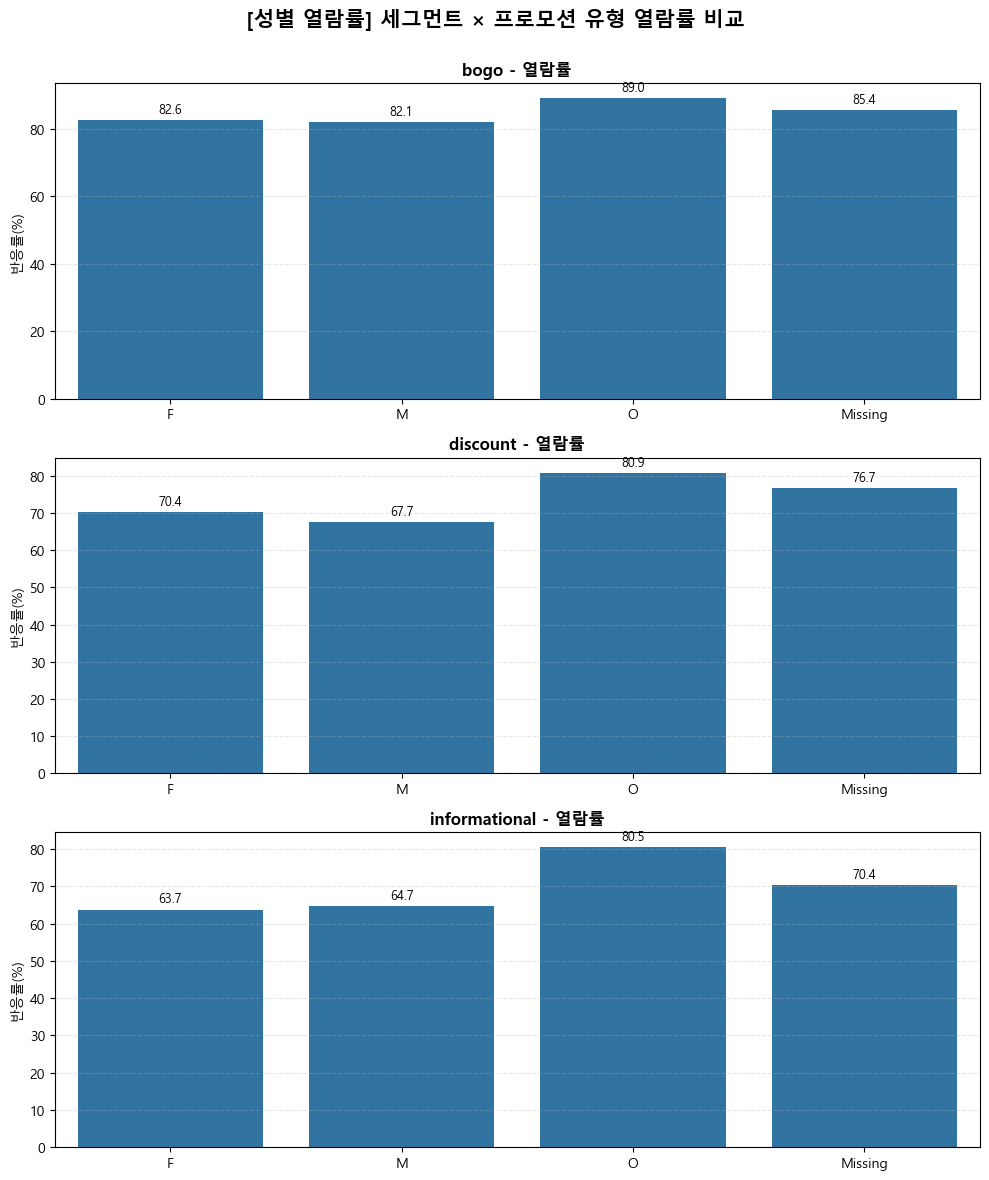

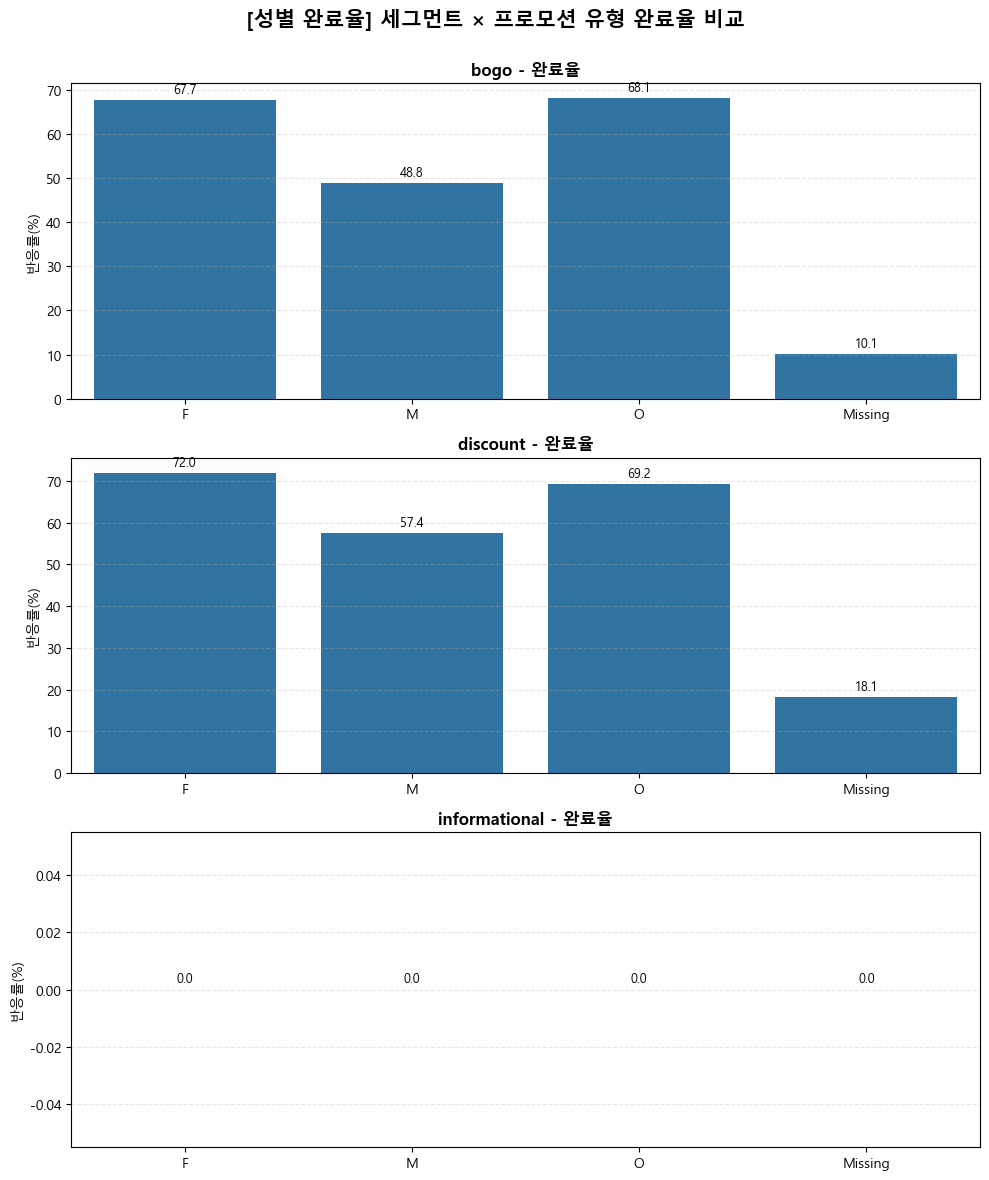

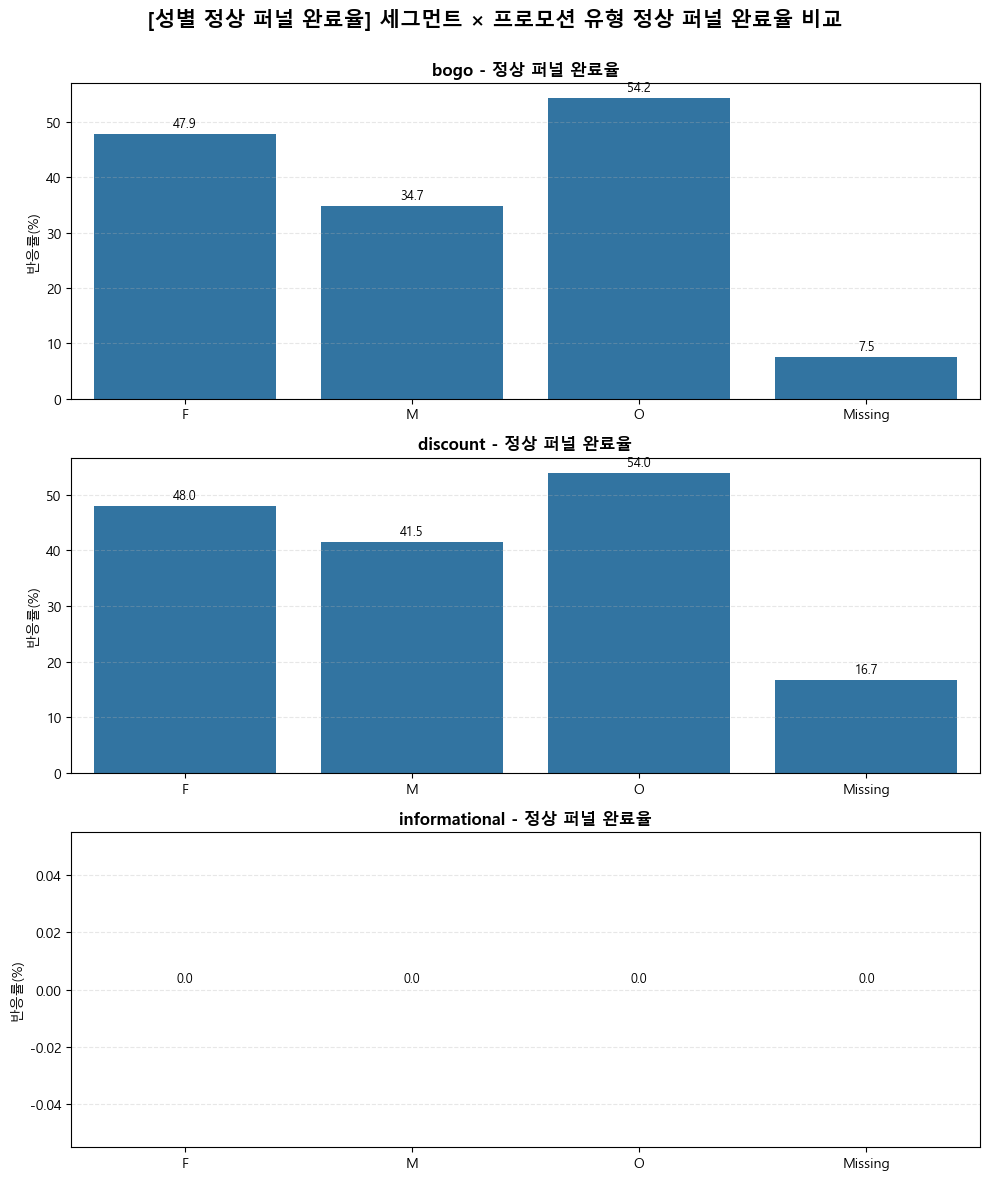

,gender_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,F,bogo,10975,9065,7434,5254,82.596811,67.735763,47.872437
3,M,bogo,15208,12485,7425,5281,82.094950,48.822988,34.725145
9,O,bogo,354,315,241,192,88.983051,68.079096,54.237288
6,Missing,bogo,3962,3385,401,297,85.436648,10.121151,7.496214
1,F,discount,10943,7700,7876,5253,70.364617,71.972951,48.003290
4,M,discount,15354,10396,8817,6374,67.708740,57.424775,41.513612
10,O,discount,367,297,254,198,80.926431,69.209809,53.950954
7,Missing,discount,3879,2977,704,647,76.746584,18.149007,16.679557
2,F,informational,5538,3530,0,0,63.741423,0.000000,0.000000
5,M,informational,7567,4898,0,0,64.728426,0.000000,0.000000


In [113]:
plot_segment_offer_box(
    gender_offer_summary, 
    'gender_group', 
    'rv_rate', 
    '성별 열람률'
)

plot_segment_offer_box(
    gender_offer_summary, 
    'gender_group', 
    'rc_rate', 
    '성별 완료율'
)

plot_segment_offer_box(
    gender_offer_summary, 
    'gender_group', 
    'rvc_rate', 
    '성별 정상 퍼널 완료율'
)

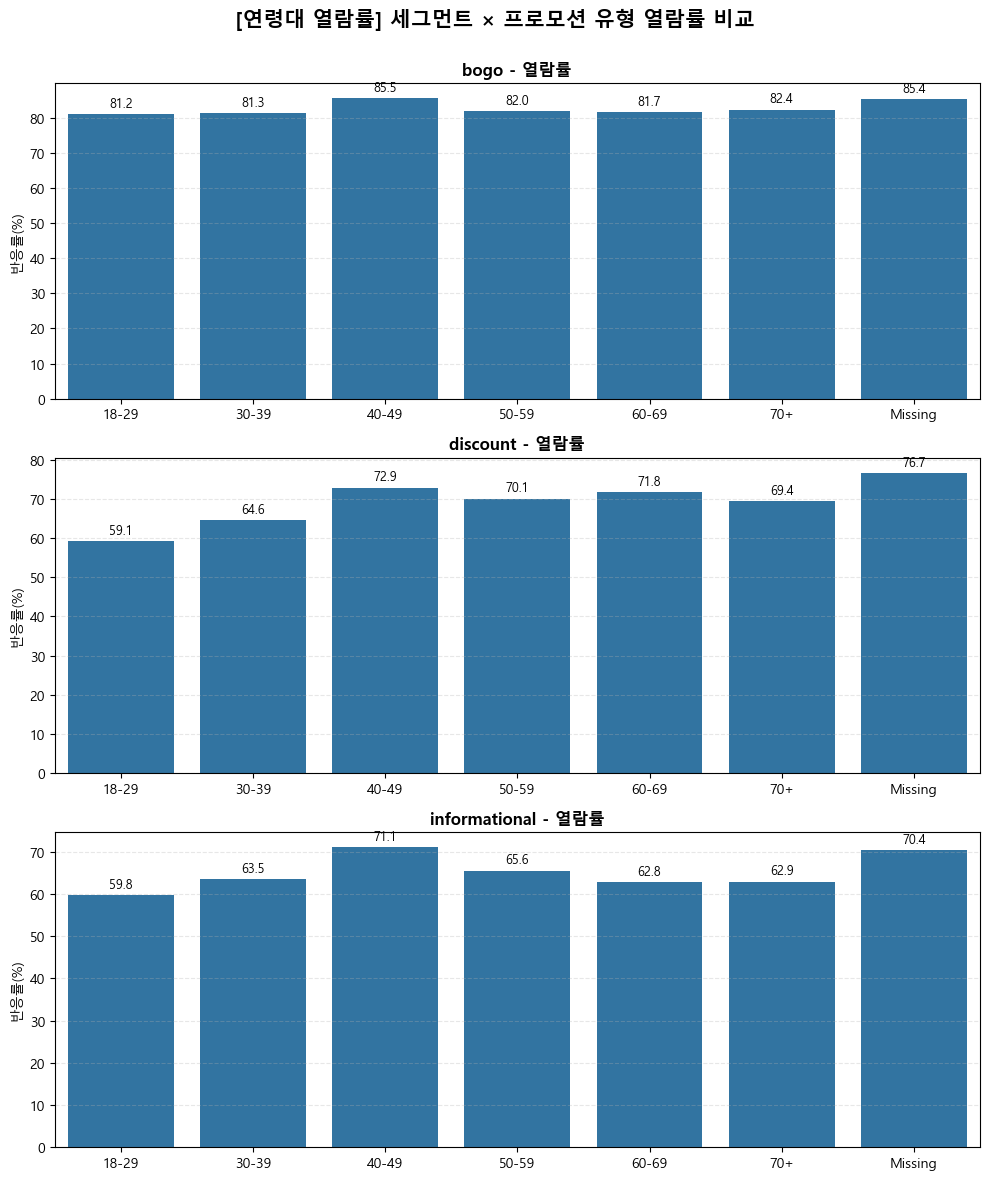

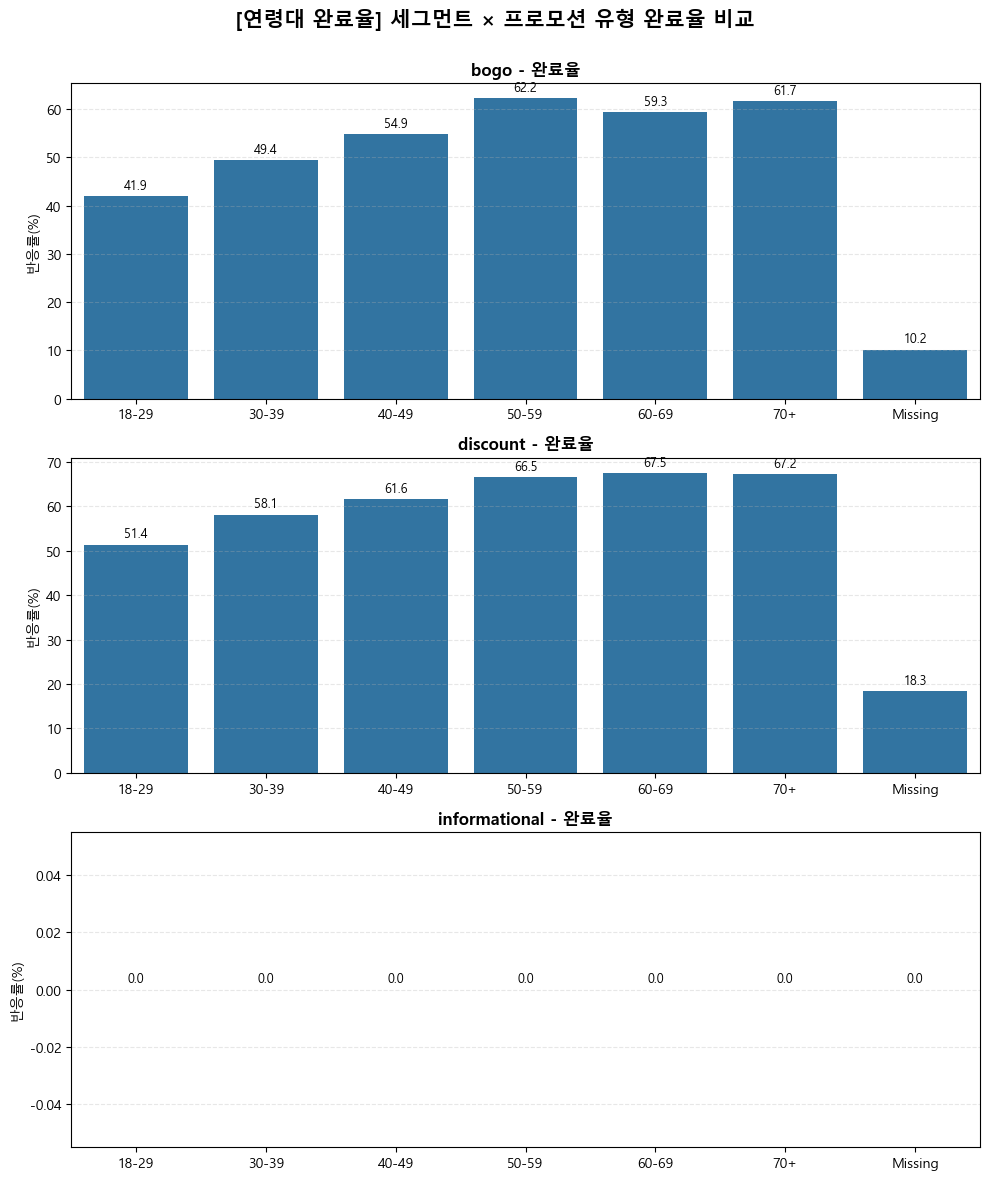

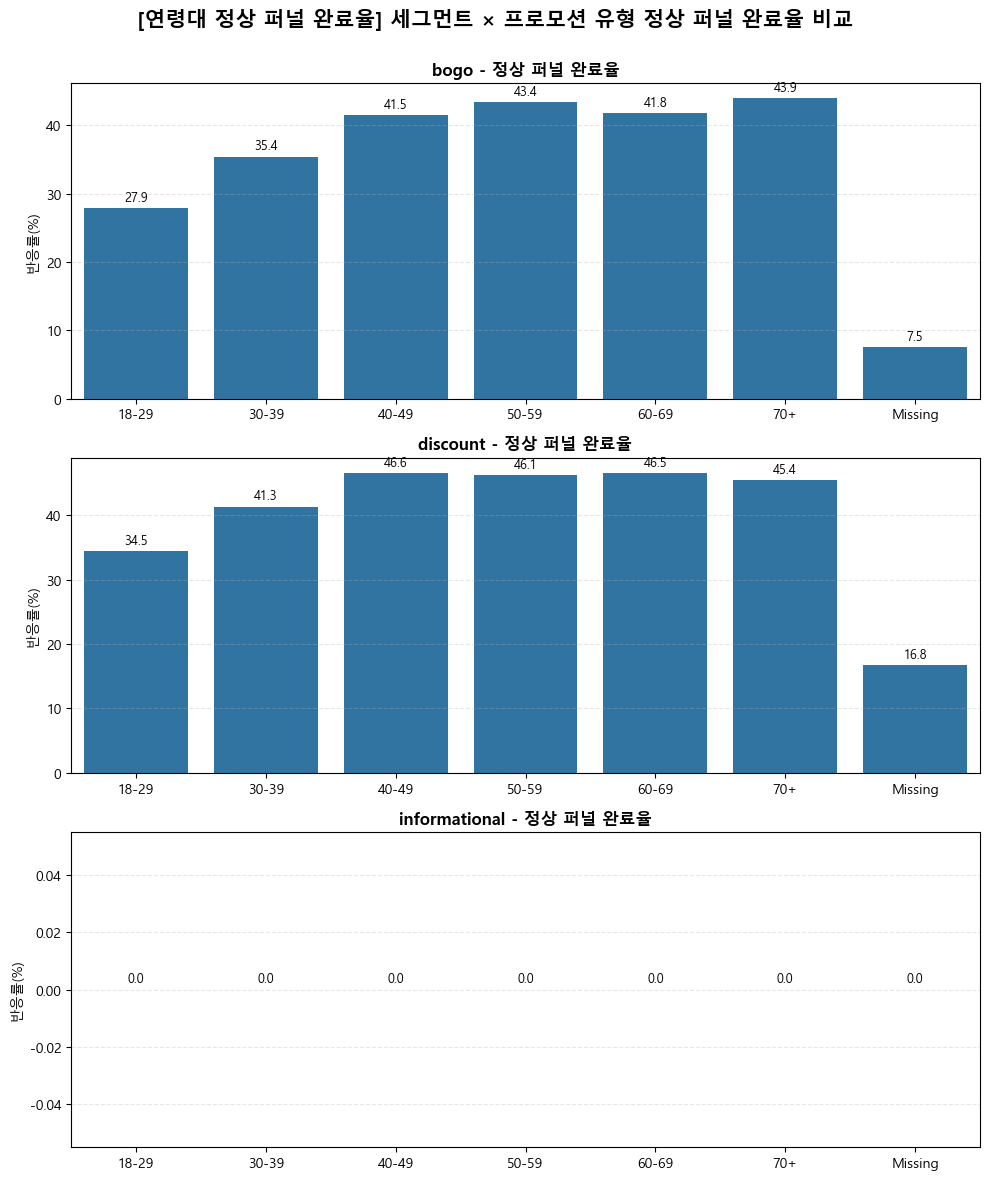

,age_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,18-29,bogo,2831,2298,1186,790,81.172730,41.893324,27.905334
3,30-39,bogo,2710,2202,1339,960,81.254613,49.409594,35.424354
6,40-49,bogo,4184,3579,2295,1738,85.540153,54.851816,41.539197
9,50-59,bogo,6322,5183,3933,2743,81.983550,62.211326,43.388168
12,60-69,bogo,5349,4369,3173,2237,81.678818,59.319499,41.820901
15,70+,bogo,5139,4232,3172,2257,82.350652,61.724071,43.919050
18,Missing,bogo,3964,3387,403,299,85.443996,10.166498,7.542886
1,18-29,discount,2888,1708,1483,995,59.141274,51.350416,34.452909
4,30-39,discount,2805,1811,1629,1159,64.563280,58.074866,41.319073
7,40-49,discount,4057,2958,2500,1889,72.911018,61.621888,46.561499


In [114]:
plot_segment_offer_box(
    age_offer_summary, 
    'age_group', 
    'rv_rate', 
    '연령대 열람률'
)

plot_segment_offer_box(
    age_offer_summary, 
    'age_group', 
    'rc_rate', 
    '연령대 완료율'
)

plot_segment_offer_box(
    age_offer_summary, 
    'age_group', 
    'rvc_rate', 
    '연령대 정상 퍼널 완료율'
)

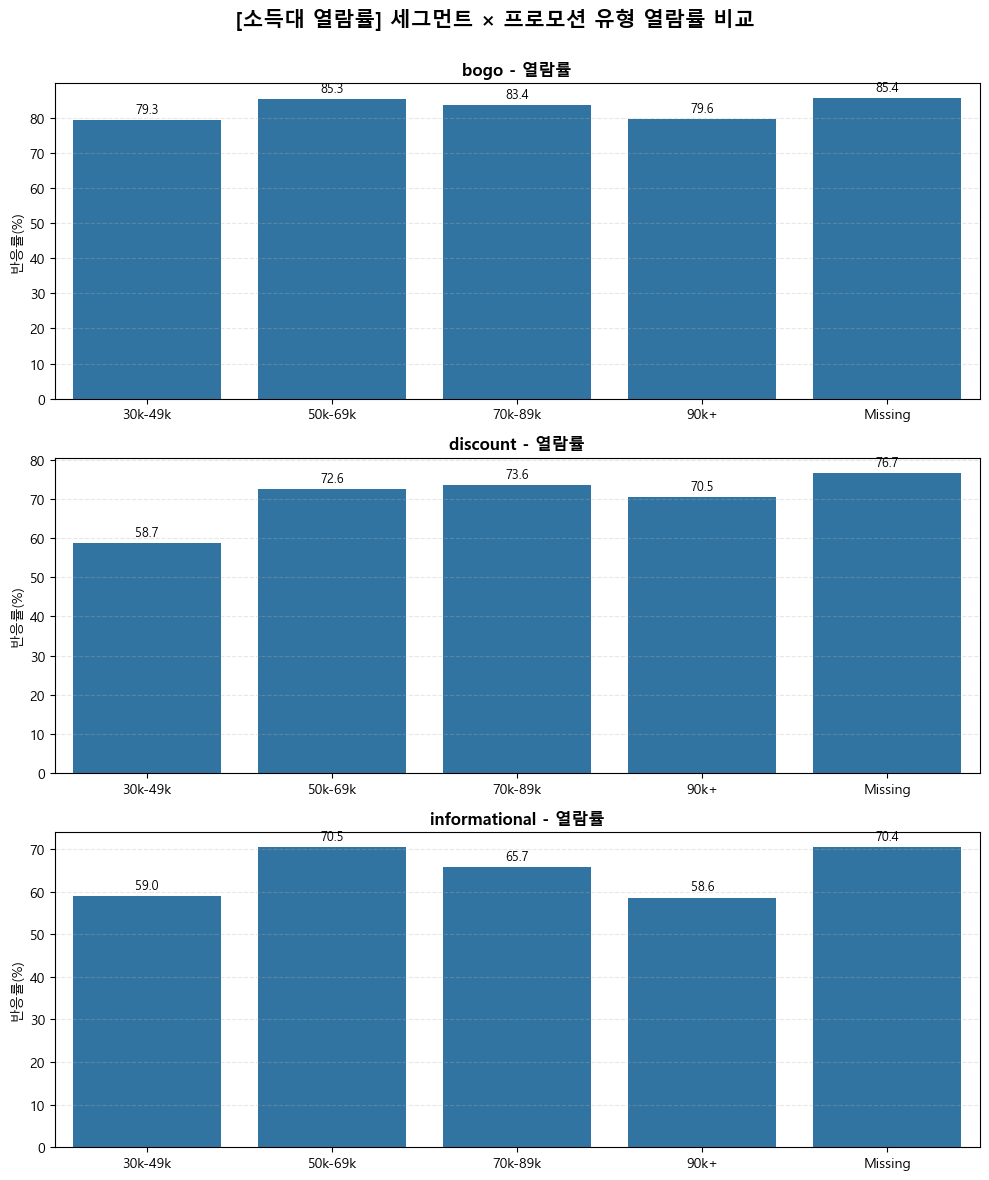

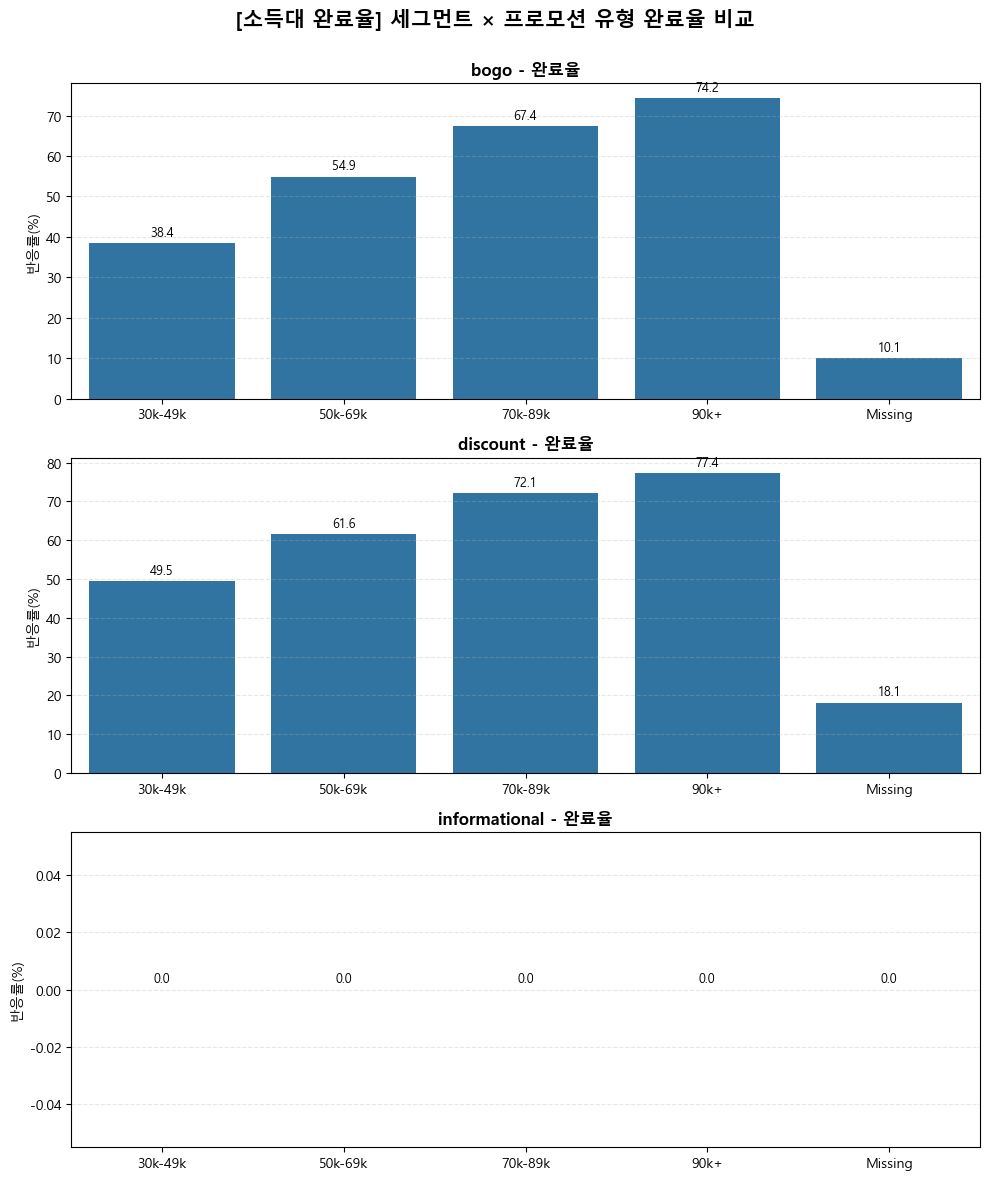

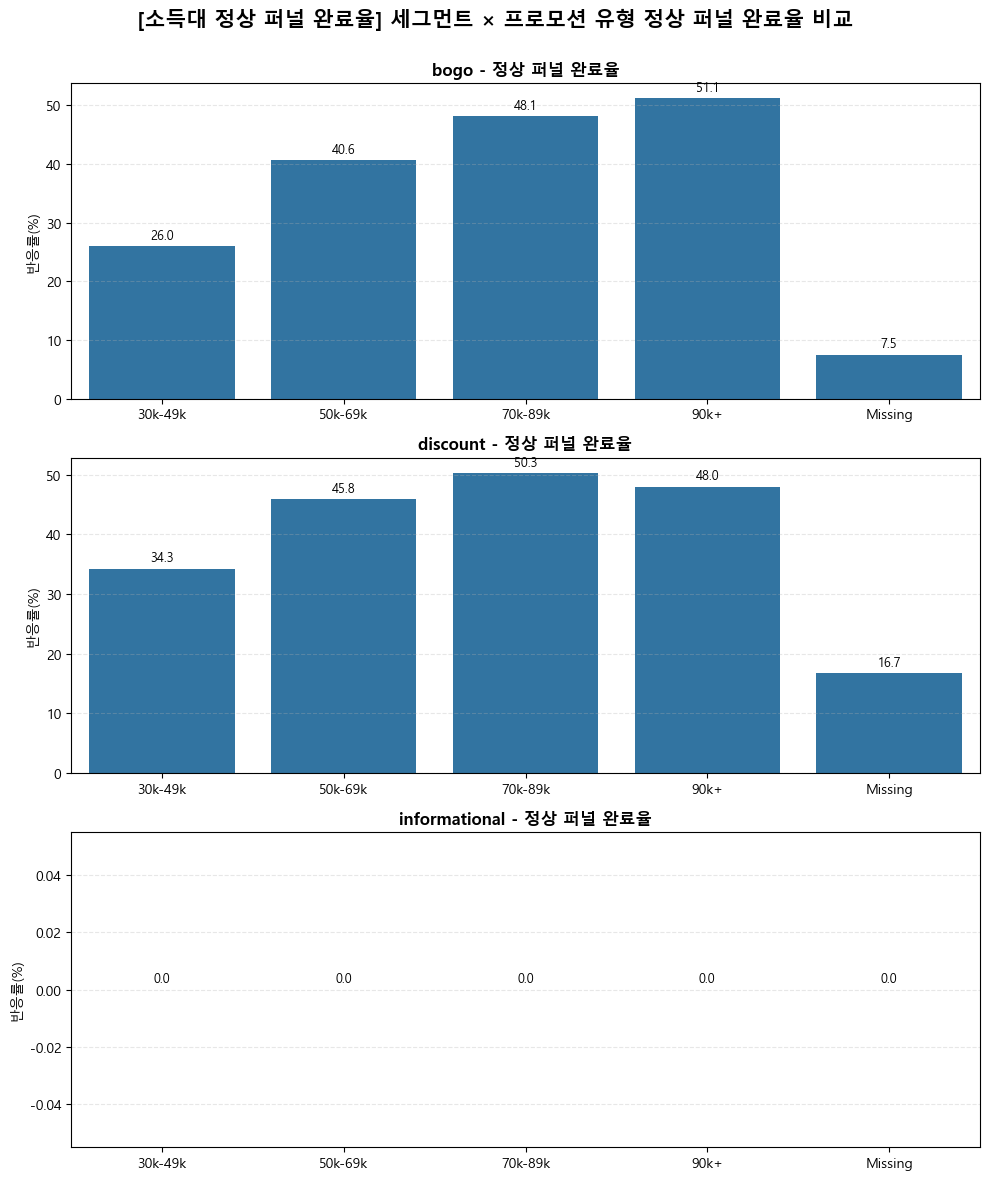

,income_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,30k-49k,bogo,6781,5379,2607,1764,79.324583,38.445657,26.013862
3,50k-69k,bogo,8886,7576,4880,3610,85.257709,54.917848,40.625703
6,70k-89k,bogo,6710,5598,4525,3226,83.427720,67.436662,48.077496
9,90k+,bogo,4160,3312,3088,2127,79.615385,74.230769,51.129808
12,Missing,bogo,3962,3385,401,297,85.436648,10.121151,7.496214
1,30k-49k,discount,6837,4012,3381,2343,58.680708,49.451514,34.269416
4,50k-69k,discount,8965,6511,5519,4110,72.626882,61.561629,45.844953
7,70k-89k,discount,6786,4995,4892,3415,73.607427,72.089596,50.324197
10,90k+,discount,4076,2875,3155,1957,70.534838,77.404318,48.012758
13,Missing,discount,3879,2977,704,647,76.746584,18.149007,16.679557


In [115]:
plot_segment_offer_box(
    income_offer_summary, 
    'income_group', 
    'rv_rate', 
    '소득대 열람률'
)

plot_segment_offer_box(
    income_offer_summary, 
    'income_group', 
    'rc_rate', 
    '소득대 완료율'
)

plot_segment_offer_box(
    income_offer_summary, 
    'income_group', 
    'rvc_rate', 
    '소득대 정상 퍼널 완료율'
)

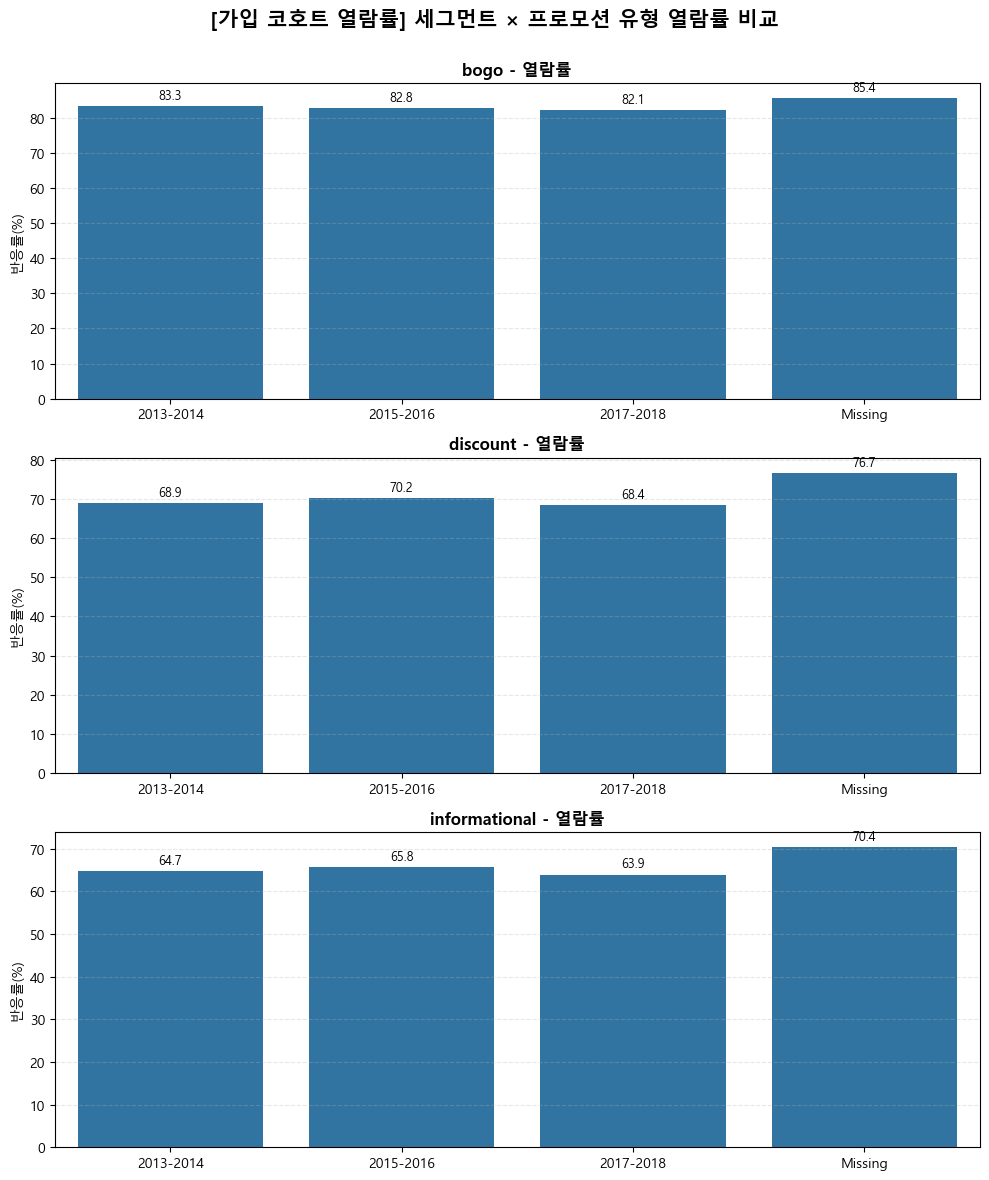

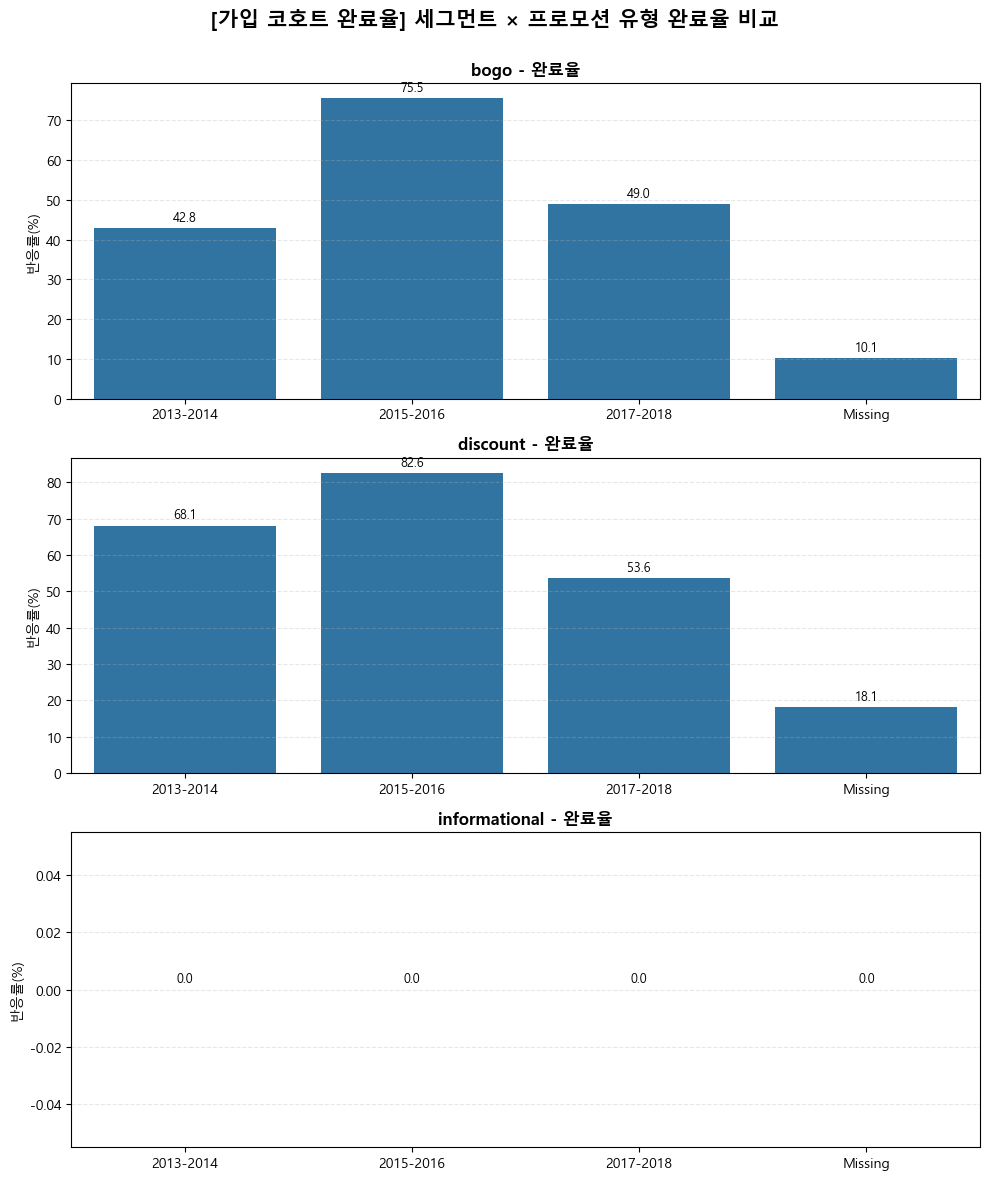

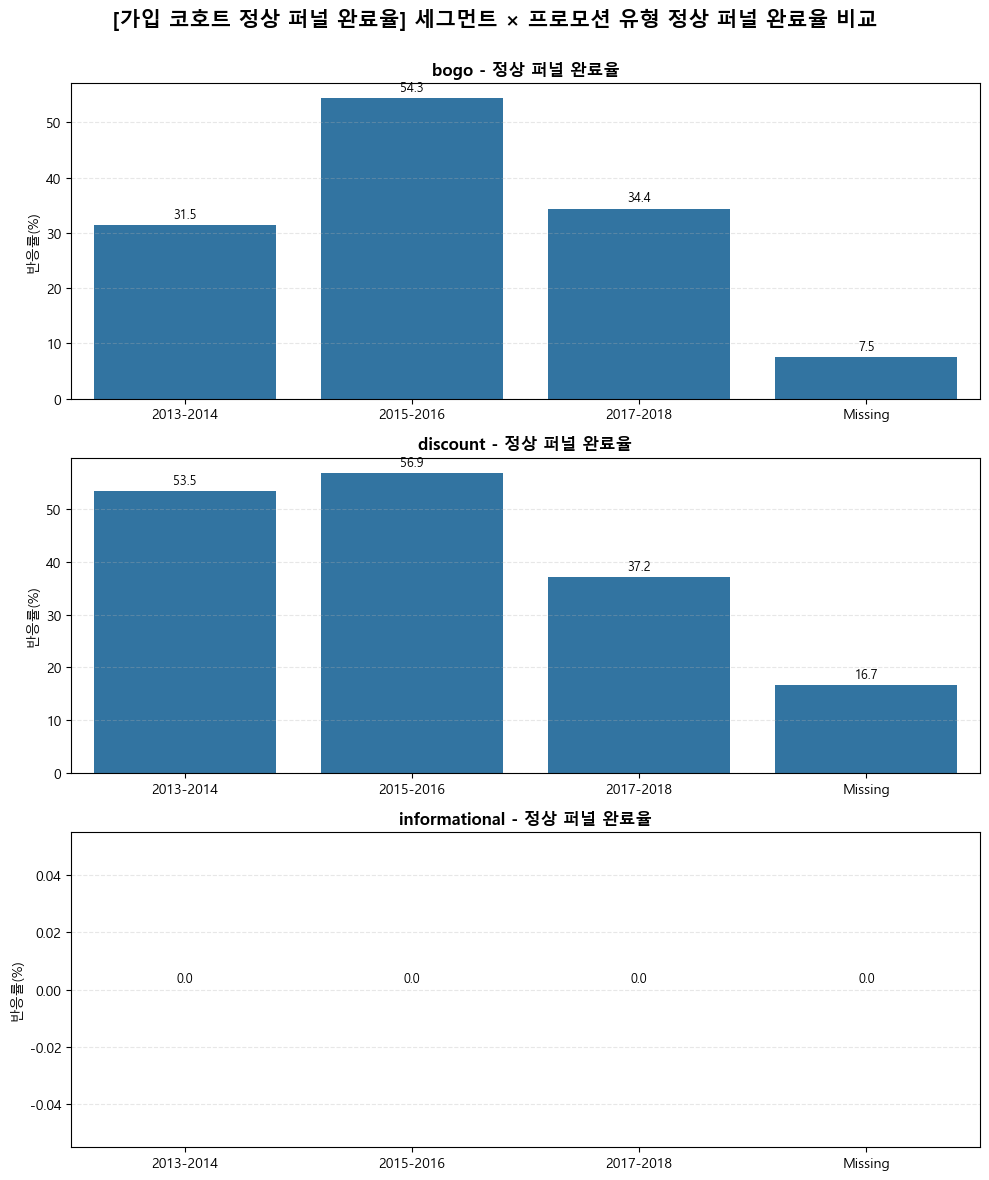

,member_cohort,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,2013-2014,bogo,1667,1388,714,525,83.263347,42.831434,31.493701
3,2015-2016,bogo,8260,6837,6239,4489,82.772397,75.532688,54.346247
6,2017-2018,bogo,16610,13640,8147,5713,82.119205,49.048766,34.394943
9,Missing,bogo,3962,3385,401,297,85.436648,10.121151,7.496214
1,2013-2014,discount,1686,1162,1148,902,68.920522,68.090154,53.499407
4,2015-2016,discount,8295,5822,6854,4720,70.186860,82.628089,56.901748
7,2017-2018,discount,16683,11409,8945,6203,68.386981,53.617455,37.181562
10,Missing,discount,3879,2977,704,647,76.746584,18.149007,16.679557
2,2013-2014,informational,846,547,0,0,64.657210,0.000000,0.000000
5,2015-2016,informational,4115,2707,0,0,65.783718,0.000000,0.000000


In [116]:
plot_segment_offer_box(
    cohort_offer_summary, 
    'member_cohort', 
    'rv_rate', 
    '가입 코호트 열람률'
)

plot_segment_offer_box(
    cohort_offer_summary, 
    'member_cohort', 
    'rc_rate', 
    '가입 코호트 완료율'
)

plot_segment_offer_box(
    cohort_offer_summary, 
    'member_cohort', 
    'rvc_rate', 
    '가입 코호트 정상 퍼널 완료율'
)

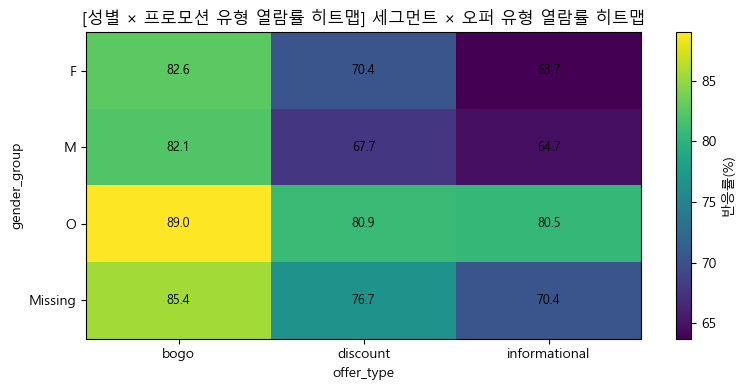

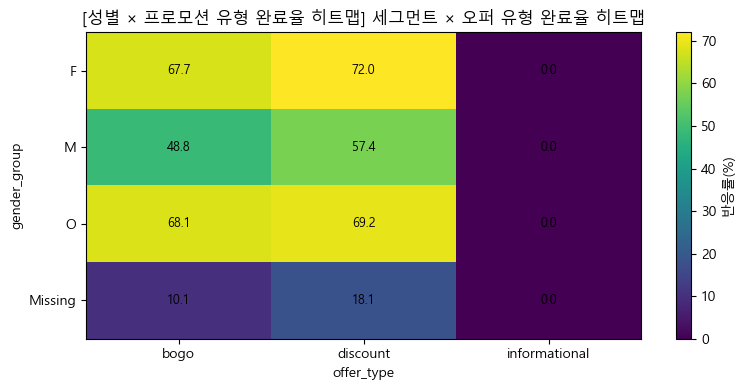

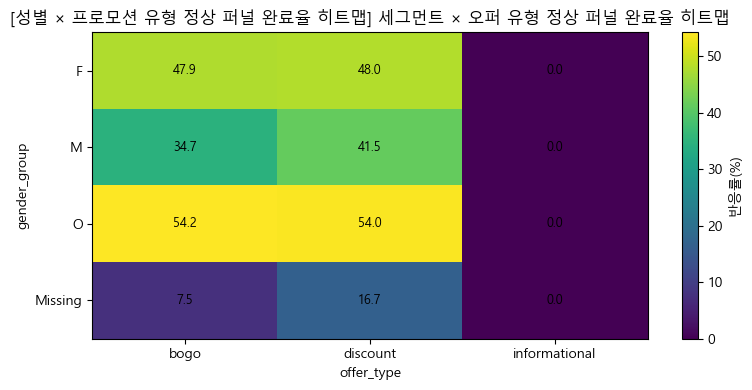

,gender_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,F,bogo,10975,9065,7434,5254,82.596811,67.735763,47.872437
1,F,discount,10943,7700,7876,5253,70.364617,71.972951,48.003290
2,F,informational,5538,3530,0,0,63.741423,0.000000,0.000000
3,M,bogo,15208,12485,7425,5281,82.094950,48.822988,34.725145
4,M,discount,15354,10396,8817,6374,67.708740,57.424775,41.513612
5,M,informational,7567,4898,0,0,64.728426,0.000000,0.000000
9,O,bogo,354,315,241,192,88.983051,68.079096,54.237288
10,O,discount,367,297,254,198,80.926431,69.209809,53.950954
11,O,informational,195,157,0,0,80.512821,0.000000,0.000000
6,Missing,bogo,3962,3385,401,297,85.436648,10.121151,7.496214


In [117]:
plot_segment_offer_heatmap(
    gender_offer_summary,
    'gender_group',
    'rv_rate',
    '성별 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    gender_offer_summary,
    'gender_group',
    'rc_rate',
    '성별 × 프로모션 유형 완료율 히트맵'
)

plot_segment_offer_heatmap(
    gender_offer_summary,
    'gender_group',
    'rvc_rate',
    '성별 × 프로모션 유형 정상 퍼널 완료율 히트맵'
)

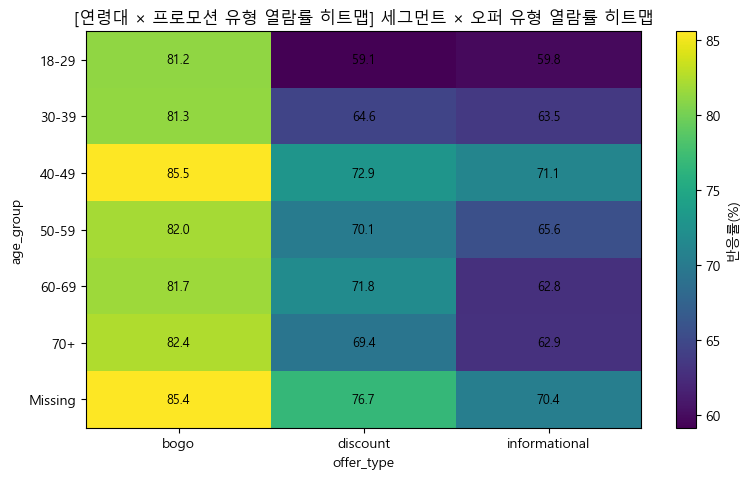

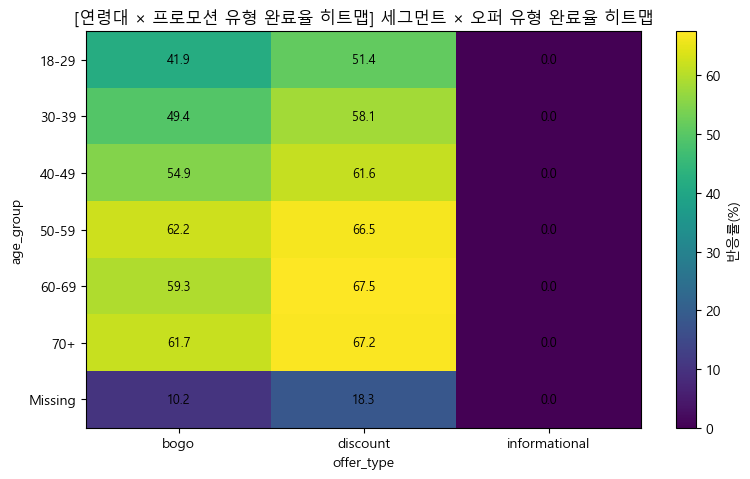

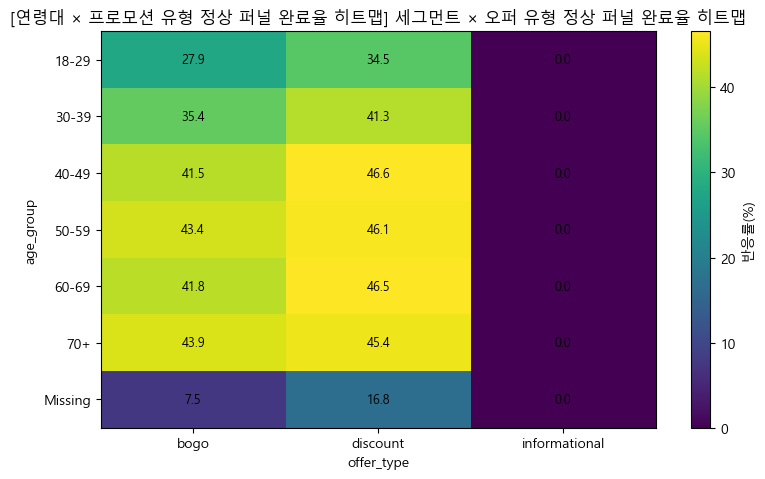

,age_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,18-29,bogo,2831,2298,1186,790,81.172730,41.893324,27.905334
1,18-29,discount,2888,1708,1483,995,59.141274,51.350416,34.452909
2,18-29,informational,1376,823,0,0,59.811047,0.000000,0.000000
3,30-39,bogo,2710,2202,1339,960,81.254613,49.409594,35.424354
4,30-39,discount,2805,1811,1629,1159,64.563280,58.074866,41.319073
5,30-39,informational,1378,875,0,0,63.497823,0.000000,0.000000
6,40-49,bogo,4184,3579,2295,1738,85.540153,54.851816,41.539197
7,40-49,discount,4057,2958,2500,1889,72.911018,61.621888,46.561499
8,40-49,informational,2047,1456,0,0,71.128481,0.000000,0.000000
9,50-59,bogo,6322,5183,3933,2743,81.983550,62.211326,43.388168


In [118]:
plot_segment_offer_heatmap(
    age_offer_summary,
    'age_group',
    'rv_rate',
    '연령대 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    age_offer_summary,
    'age_group',
    'rc_rate',
    '연령대 × 프로모션 유형 완료율 히트맵'
)

plot_segment_offer_heatmap(
    age_offer_summary,
    'age_group',
    'rvc_rate',
    '연령대 × 프로모션 유형 정상 퍼널 완료율 히트맵'
)


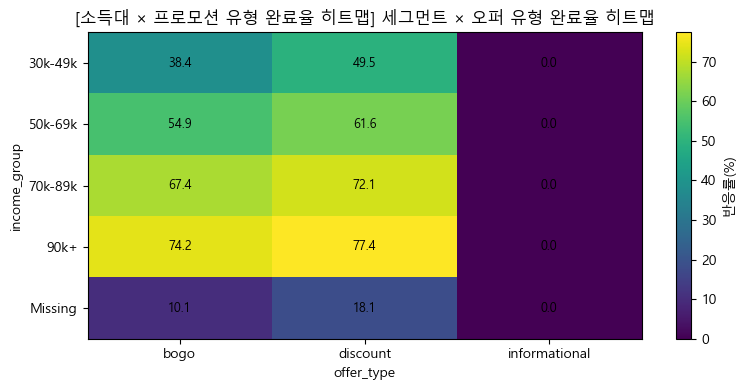

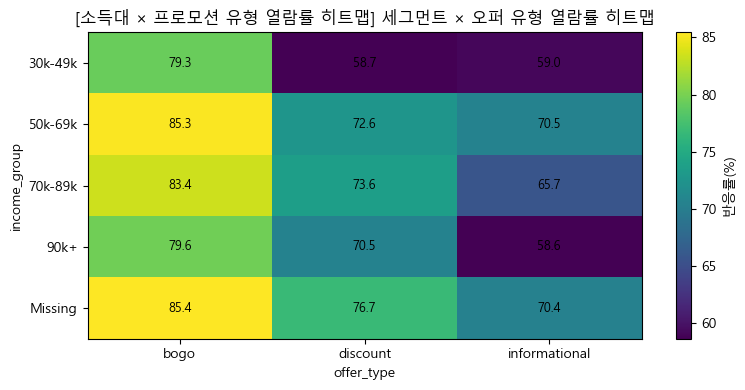

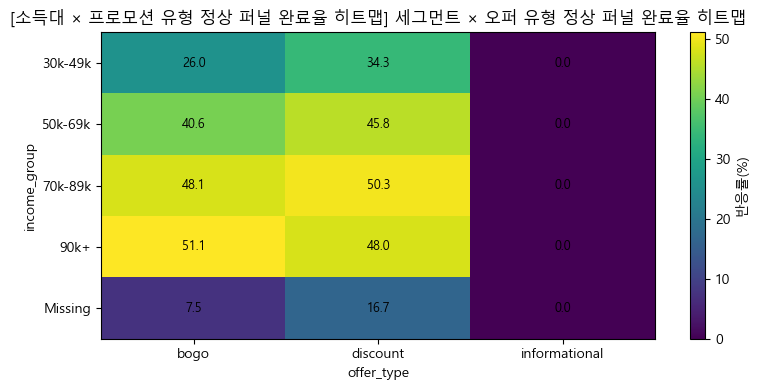

,income_group,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,30k-49k,bogo,6781,5379,2607,1764,79.324583,38.445657,26.013862
1,30k-49k,discount,6837,4012,3381,2343,58.680708,49.451514,34.269416
2,30k-49k,informational,3349,1977,0,0,59.032547,0.000000,0.000000
3,50k-69k,bogo,8886,7576,4880,3610,85.257709,54.917848,40.625703
4,50k-69k,discount,8965,6511,5519,4110,72.626882,61.561629,45.844953
5,50k-69k,informational,4577,3226,0,0,70.482849,0.000000,0.000000
6,70k-89k,bogo,6710,5598,4525,3226,83.427720,67.436662,48.077496
7,70k-89k,discount,6786,4995,4892,3415,73.607427,72.089596,50.324197
8,70k-89k,informational,3287,2159,0,0,65.682994,0.000000,0.000000
9,90k+,bogo,4160,3312,3088,2127,79.615385,74.230769,51.129808


In [119]:
plot_segment_offer_heatmap(
    income_offer_summary,
    'income_group',
    'rc_rate',
    '소득대 × 프로모션 유형 완료율 히트맵'
)

plot_segment_offer_heatmap(
    income_offer_summary,
    'income_group',
    'rv_rate',
    '소득대 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    income_offer_summary,
    'income_group',
    'rvc_rate',
    '소득대 × 프로모션 유형 정상 퍼널 완료율 히트맵'
)


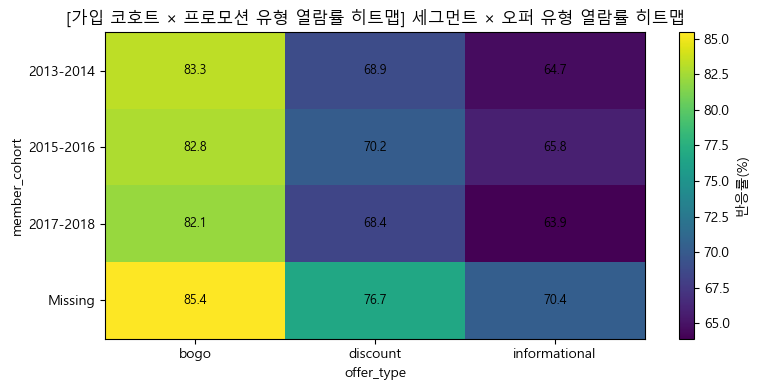

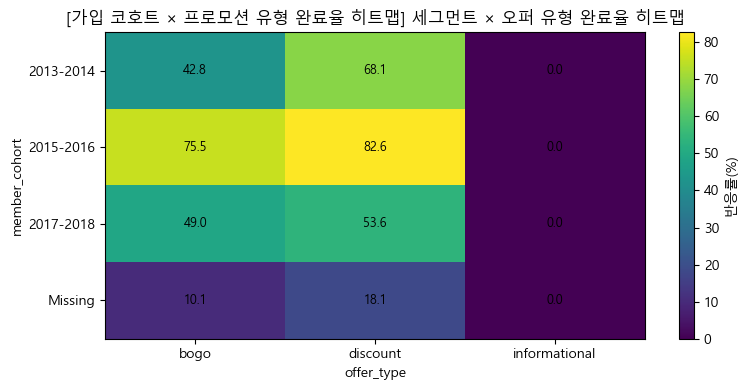

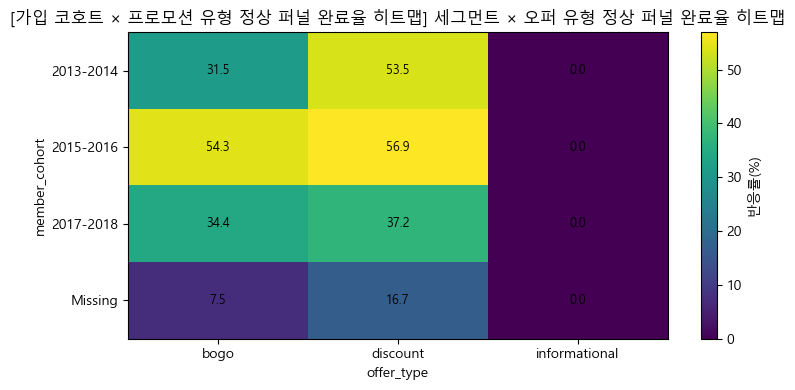

,member_cohort,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,2013-2014,bogo,1667,1388,714,525,83.263347,42.831434,31.493701
1,2013-2014,discount,1686,1162,1148,902,68.920522,68.090154,53.499407
2,2013-2014,informational,846,547,0,0,64.657210,0.000000,0.000000
3,2015-2016,bogo,8260,6837,6239,4489,82.772397,75.532688,54.346247
4,2015-2016,discount,8295,5822,6854,4720,70.186860,82.628089,56.901748
5,2015-2016,informational,4115,2707,0,0,65.783718,0.000000,0.000000
6,2017-2018,bogo,16610,13640,8147,5713,82.119205,49.048766,34.394943
7,2017-2018,discount,16683,11409,8945,6203,68.386981,53.617455,37.181562
8,2017-2018,informational,8339,5331,0,0,63.928529,0.000000,0.000000
9,Missing,bogo,3962,3385,401,297,85.436648,10.121151,7.496214


In [120]:
plot_segment_offer_heatmap(
    cohort_offer_summary,
    'member_cohort',
    'rv_rate',
    '가입 코호트 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    cohort_offer_summary,
    'member_cohort',
    'rc_rate',
    '가입 코호트 × 프로모션 유형 완료율 히트맵'
)

plot_segment_offer_heatmap(
    cohort_offer_summary,
    'member_cohort',
    'rvc_rate',
    '가입 코호트 × 프로모션 유형 정상 퍼널 완료율 히트맵'
)


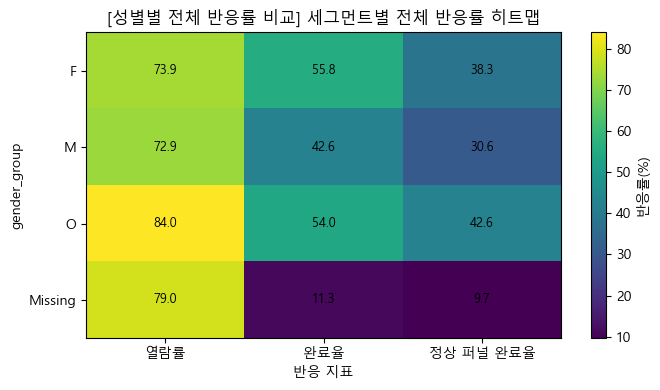

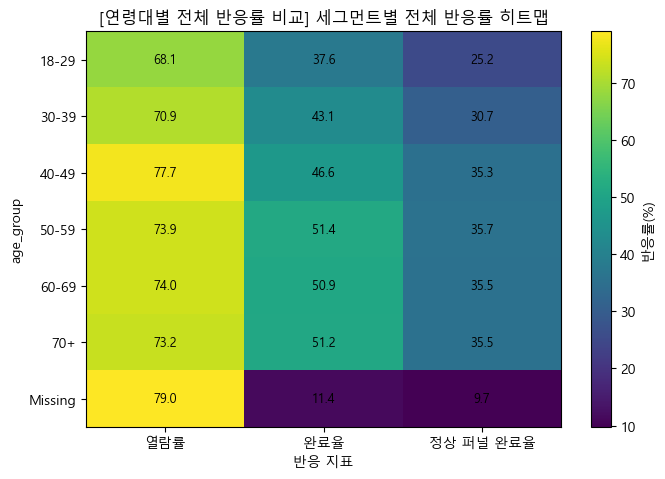

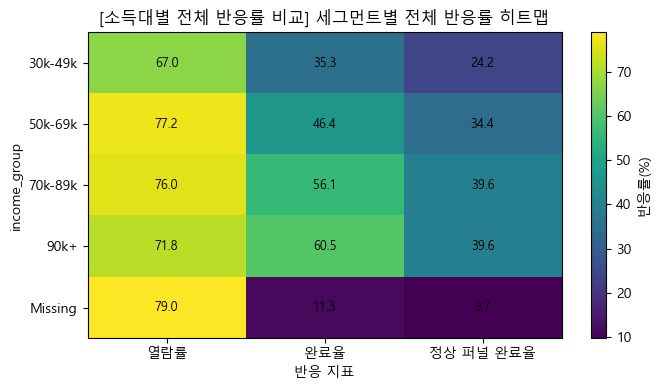

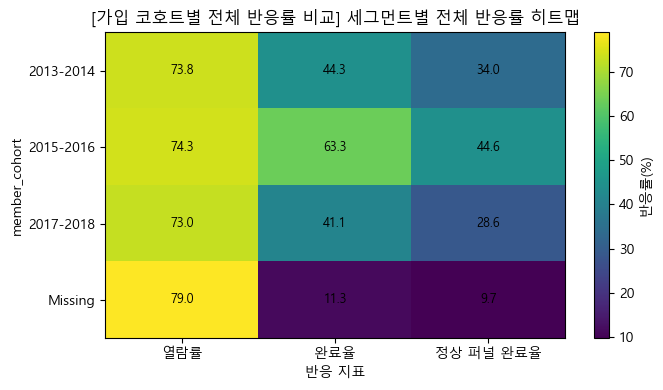

,member_cohort,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
3,2013-2014,4199,3097,1862,1427,73.755656,44.343891,33.984282
1,2015-2016,20670,15366,13093,9209,74.339623,63.343009,44.552492
0,2017-2018,41632,30380,17092,11916,72.972713,41.054958,28.622214
2,Missing,9776,7724,1105,944,79.009820,11.303191,9.656301


In [121]:
plot_segment_summary_heatmap(
    gender_summary, 
    'gender_group', 
    '성별별 전체 반응률 비교'
)

plot_segment_summary_heatmap(
    age_summary, 
    'age_group', 
    '연령대별 전체 반응률 비교'
)

plot_segment_summary_heatmap(
    income_summary, 
    'income_group', 
    '소득대별 전체 반응률 비교'
)

plot_segment_summary_heatmap(
    cohort_summary, 
    'member_cohort', 
    '가입 코호트별 전체 반응률 비교'
)

# 종합 보고서

- received → viewed : 열람률
    - 오퍼가 실제로 고객에게 읽혔는가

- received → completed : 전체 완료율
    - 오퍼를 받은 사람 중 최종적으로 조건 충족까지 간 비율
    
- received → viewed → completed : 정상 퍼널 완료율
    - received 이후 viewed를 거치고, 그 다음 completed까지 순서대로 간 비율

## 1. 성별 세그먼트 해석
성별 전체 반응률을 보면\
여성(F)은 열람률 73.9%, 완료율 55.8%, 정상 퍼널 완료율 38.3%로 나타났다.\
남성(M)은 열람률 72.9%로 비슷하지만 완료율은 42.6%, 정상 퍼널 완료율은 30.6%로 더 낮았다.
> **오퍼를 보는 비율은 성별 간 큰 차이가 없지만**, **완료까지 이어지는 힘은 여성 쪽이 더 강한 편이다.**

오퍼 유형별 차이는 다음과 같다.\
bogo 완료율은 여성 67.7%, 남성 48.8%였고,\
discount 완료율도 여성 72.0%, 남성 57.4%로 **여성이 더 높게 나타났다.**

정상 퍼널 완료율 역시 bogo에서 여성 47.9%, 남성 34.7%,\
discount에서 여성 48.0%, 남성 41.5%로 **여성이 더 높게 나타났다.**

반면 열람률 자체는 성별 차이가 아주 크지는 않았다.\
bogo 열람률은 여성 82.6%, 남성 82.1%로 거의 비슷했고,\
discount에서는 여성 70.4%, 남성 67.7%,\
informational에서는 여성 63.7%, 남성 64.7% 수준으로 나타났다.

결론적으로 성별 관점에선\
**남녀가 오퍼를 보는 수준은 비슷하지만, 실제 반응을 행동으로 마무리하는 비율은 여성이 더 높다**고 해석할 수 있다.\
즉, bogo, discount 오퍼에서 여성 고객군이 상대적으로 더 강한 반응층이라고 볼 수 있다.

> O, Missing 그룹은 수가 적거나 정보 결측의 영향이 있을 수 있어,\
수치 자체는 참고하되 과도한 일반화는 주의 필요

## 2. 연령대 세그먼트 해석
연령대 전체 반응률을 보면\
18–29세는 열람률 68.1%, 완료율 37.6%, 정상 퍼널 완료율 25.2%로 나타났다.\
50–59세는 완료율 51.4%,\
60–69세는 50.9%,\
70세 이상은 51.2%로 나타났다.\
즉, 연령대가 높아질수록 완료율이 전반적으로 상승하는 흐름을 보인다.

열람률은 40–49세가 77.7%로 가장 높았고,\
50대 이상도 대체로 73~74% 수준을 유지했다.\
반면 20대는 열람률 자체가 68.1%로 낮아,\
처음 오퍼를 확인하는 단계부터 반응이 약한 편이라고 볼 수 있다.

오퍼 유형별 차이는 다음과 같다.\
bogo 완료율은 18–29세 41.9%에서 시작해\
50–59세 62.2%, 70세 이상 61.7%까지 올라간다.

discount 완료율도 18–29세 51.4%, 30–39세 58.1%,\
50대 이상은 66%~67%대로 더 높다.

열람률 측면에서는 bogo가 거의 모든 연령대에서 81~85% 수준으로 나타났으나\
discount와 informational은 연령대가 낮을수록 낮아지고,\
40대 이후부터 상대적으로 높아지는 모습이 보인다.

결론적으로 연령대 관점에선\
**젊은 층은 오퍼 확인과 완료 모두 상대적으로 약하고**\
**중장년층은 특히 discount, bogo 오퍼에 더 안정적으로 반응한다는 뜻으로 해석할 수 있다.**\
따라서 40대 이상 고객군을 주요 반응층으로 보고,\
20대는 오퍼 구조 자체보다 다른 요소로의 접근을 별도로 확인할 필요가 있다.


## 3. 소득대 세그먼트 해석
소득대 전체 반응률을 보면\
30k–49k는 열람률 67.0%, 완료율 35.3%, 정상 퍼널 완료율 24.2%로 가장 낮게 나왔다.\
70k–89k는 완료율 56.1%,\
90k+는 60.5%로 가장 높게 나타났다.\
즉, **소득 수준이 높아질수록 완료율이 상승하는 경향을 띈다**\

오퍼 유형별 차이는 다음과 같다.\
bogo 완료율은 
30k–49k 38.4%\
50k–69k 54.9%\
70k–89k 67.4%\
90k+ 74.2%로 차이가 발생하는것을 확인할수 있다.\
discount 완료율도 49.5% → 61.6% → 72.1% → 77.4%로 상승한다.

정상 퍼널 완료율은\
bogo에서 26.0% → 40.6% → 48.1% → 51.1%,\
discount에서 34.3% → 45.8% → 50.3% → 48.0% 수준으로 높아진다.

결론적으로 소득대 관점에선\
**소득이 높을수록** 오퍼를 실제 행동으로 옮기는 비율이 높다.\
특히 bogo, discount처럼 완료가 필요한 프로모션에서 그 차이가 크게 드러난다.\
따라서 반응률 중심 타겟팅을 한다면 중·고소득 고객군이 핵심 타겟이 될 수 있다.\

저소득층은 열람과 완료가 모두 낮게 나타났기 때문에 프로모션 보다 다른 혜택 구조나 채널 전략이 필요해 보인다.


## 4. 가입 코호트 해석
가입 코호트 전체 반응률을 보면\
2015–2016 가입 고객의 완료율이 63.3%, 정상 퍼널 완료율이 44.6%로 가장 높았다.\
2013–2014는 완료율 44.3%,\
2017–2018은 41.1%로 상대적으로 낮았다.\
즉, 가입 시점에 따라 반응 차이가 존재하며, 특히 2015–2016 코호트가 가장 강한 반응층으로 보인다.

오퍼 유형별 차이는 다음과 같다.\
bogo 완료율은\
2013–2014가 42.8%,\
2015–2016이 75.5%,\
2017–2018이 49.0%였다.

discount 완료율은\
2013–2014는 68.1%,\
2015–2016은 82.6%,\
2017–2018은 53.6%였다.

정상 퍼널 완료율에선\
2015–2016 코호트가 bogo 54.3%, discount 56.9%로 가장 높았다.

열람률은 세 코호트 모두 큰 차이는 없었다\
bogo는 모두 82~83% 수준,\
discount도 68~70% 수준,\
informational도 63~66% 수준으로 나타났다

결론적으로 가입 코호트 관점에선\
2015–2016 코호트는 주요 프로모션에서 높은 성과를 보이므로, 우선 타겟군으로 해석할 수 있다.

# 5. 최종해석

1. 성별 기준으로는 여성이 남성보다 완료율이 더 높았다.
2. 연령대 기준으로는 40대 이상, 특히 50대 이상에서 반응이 더 안정적이었다.
3. 소득 기준으로는 중·고소득층일수록 완료율이 높았다.
4. 가입 코호트 기준으로는 2015–2016 가입 고객이 가장 강한 반응층이었다.

만약, 반응률 중심의 타겟팅 전략을 세운다면\
우선적으로는 중장년층, 중·고소득층, 그리고 2015–2016 가입 코호트를 핵심 타겟으로 볼 수 있다.